# Clinical Trial Sponsor Intelligence Engine: End-to-End Data Science Project
### **Prepared by** Sandipan Acharjee

To access other associated files for this project (Notebooks, Source_code, root files, Dataset, pickel files, Dockerfile, API, insight & EDA visualisation etc.) [Click Here]()

To have a quick demo on the Sponsor level dashboard & Report [Click Here]()

---

From Raw Data scraped from [www.ClinicalTrials.gov](https://clinicaltrials.gov/about-site/about-ctg) to Strategic Healthcare Forecasting. This Project aims to produce a reusable ML model to prepare Sponsor level insights, their Clinical Research trends, Performance of Clinical Trials, Drug development lifecycle, ultimately a full single-image intelligence report for  that sponsor covering trial volume, failure rates by phase, domain focus,  enrollment patterns, and duration distributions.

## Project Overview
The Object of this project is to explore and analyse the current landscape of the clinical trials studied from the period of 2005 to 2025 to deep dive into the
trends, global insights and current scenario for future drug development and clinical studies scopes and investment and return potential of Pharmaceutical
Research and Development


In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    ConfusionMatrixDisplay, roc_curve
)
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
import warnings

warnings.filterwarnings("ignore")

# a clean visual style across all plots
plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

print("Environment ready.")

Environment ready.


### 1. Loading the Data

We are working with a dataset pulled from ClinicalTrials.gov covering trials between 2005 and 2025. Each row is a single clinical trial.

In [29]:
df_raw = pd.read_csv("raw_ct_data.csv")

print(f"Dataset dimensions: {df_raw.shape[0]} trials, {df_raw.shape[1]} columns")
print()
print("Column names and data types:")
print(df_raw.dtypes)
print()
print("First three rows:")
df_raw.head(3)

Dataset dimensions: 3792 trials, 23 columns

Column names and data types:
NCT Number                        str
Study Title                       str
Study URL                         str
Study Status                      str
Brief Summary                     str
Study Results                     str
Conditions                        str
Interventions                     str
Primary Outcome Measures          str
Secondary Outcome Measures        str
Sponsor                           str
Collaborators                     str
Sex                               str
Age                               str
Phases                            str
Enrollment                    float64
Funder Type                       str
Study Type                        str
Study Design                      str
Start Date                        str
Completion Date                   str
Locations                         str
Study Documents                   str
dtype: object

First three rows:


,NCT Number,Study Title,Study URL,Study Status,Brief Summary,Study Results,Conditions,Interventions,Primary Outcome Measures,Secondary Outcome Measures,...,Age,Phases,Enrollment,Funder Type,Study Type,Study Design,Start Date,Completion Date,Locations,Study Documents
0,NCT07450833,"Safety, Tolerability and Pharmacokinetics of B...",https://clinicaltrials.gov/study/NCT07450833,COMPLETED,The goal of this clinical trial was to learn a...,YES,Healthy Volunteers,DRUG: Benfo-oxythiamine,Number of Participants With Treatment-Emergent...,Single Ascending Dose (SAD): Maximum Plasma Co...,...,ADULT,PHASE1,48.0,INDUSTRY,INTERVENTIONAL,Allocation: NON_RANDOMIZED | Intervention Mode...,01-03-2022,21-11-2022,Diagnostics and Consultation Center (DCC) Conv...,"Study Protocol, https://cdn.clinicaltrials.gov..."
1,NCT07214935,A TQT Study of Effect of M2951 on Cardiac Repo...,https://clinicaltrials.gov/study/NCT07214935,COMPLETED,The purpose of this study is to assess potenti...,YES,Healthy,DRUG: Placebo matched to M2951|DRUG: Moxifloxa...,Placebo-corrected Change From Baseline in Corr...,Placebo-corrected Change From Baseline in Corr...,...,ADULT,PHASE1,36.0,INDUSTRY,INTERVENTIONAL,Allocation: RANDOMIZED | Intervention Model: C...,08-11-2022,25-08-2023,"Nuvisan GmbH, Neu-Ulm, Germany","Study Protocol, https://cdn.clinicaltrials.gov..."
2,NCT07214922,Relative Bioavailability of Evobrutinib Tablet...,https://clinicaltrials.gov/study/NCT07214922,COMPLETED,The main purpose of the study is to compare th...,YES,Healthy,DRUG: Treatment A|DRUG: Treatment B|DRUG: Trea...,Area Under the Plasma Concentration-time Curve...,Number of Participants With Treatment- Emergen...,...,ADULT,PHASE1,28.0,INDUSTRY,INTERVENTIONAL,Allocation: RANDOMIZED | Intervention Model: C...,18-01-2023,24-02-2023,"Nuvisan GmbH, Neu-Ulm, 89231, Germany","Study Protocol, https://cdn.clinicaltrials.gov..."


What we see: 3,792 clinical trials across 23 columns. The columns cover trial metadata (NCT number, title), operational fields (status, phase, enrollment), commercial context (sponsor, funder type), and temporal markers (start date, completion date).

---


### 2. Data Cleaning
#### 2.1 Understanding Missingness
Real-world healthcare data is never clean out of the box. Before we trust any number, we need to know where the gaps are and why they exist.

In [30]:
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)

missing_report = pd.DataFrame({
    "Missing Count": missing,
    "Missing Percent": missing_pct
}).query("`Missing Count` > 0").sort_values("Missing Percent", ascending=False)

print("Columns with missing values:")
print(missing_report)

Columns with missing values:
                            Missing Count  Missing Percent
Collaborators                        2457            64.79
Secondary Outcome Measures            814            21.47
Locations                              63             1.66
Study Documents                        30             0.79
Sponsor                                28             0.74
Sex                                    28             0.74
Phases                                 28             0.74
Age                                    28             0.74
Enrollment                             28             0.74
Funder Type                            28             0.74
Study Design                           28             0.74
Study Type                             28             0.74
Completion Date                        28             0.74
Start Date                             28             0.74


missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)

missing_report = pd.DataFrame({
    "Missing Count": missing,
    "Missing Percent": missing_pct
}).query("`Missing Count` > 0").sort_values("Missing Percent", ascending=False)

print("Columns with missing values:")
print(missing_report)

**Statistical note:** When missingness is not random (MCAR) but tied to the data itself (MAR or MNAR), dropping rows introduces bias. For example, trials without a Sponsor listed are likely incomplete submissions and are different in character from trials with full data. We will handle each case deliberately.

In [31]:
# collaborators is missing in 65% of rows which is expected because
# many trials are solo-sponsored. we will treat NaN as "no collaborator".
df_raw["Collaborators"] = df_raw["Collaborators"].fillna("None")

# rows where Sponsor itself is missing are essentially incomplete records.
# they are only 28 rows out of 3792 which is less than 1%. safe to drop.
df = df_raw.dropna(subset=["Sponsor", "Phases", "Start Date", "Completion Date",
                             "Enrollment", "Funder Type", "Study Type"]).copy()

print(f"Rows after dropping incomplete core records: {df.shape[0]}")

Rows after dropping incomplete core records: 3764


### 2.2 Parsing Dates and Deriving Duration
Dates are stored as strings in DD-MM-YYYY format. We convert them to proper datetime objects and then calculate the trial duration in months, a critical proxy for R&D investment intensity.

In [32]:
df["Start Date"] = pd.to_datetime(df["Start Date"], dayfirst=True, errors="coerce")
df["Completion Date"] = pd.to_datetime(df["Completion Date"], dayfirst=True, errors="coerce")

# duration in months = difference in days / 30.44 (average days per month)
df["Duration_Months"] = (
    (df["Completion Date"] - df["Start Date"]).dt.days / 30.44
).round(1)

# negative or zero durations are data entry errors. remove them.
df = df[df["Duration_Months"] > 0].copy()

# extract the start year for time series work
df["Start_Year"] = df["Start Date"].dt.year

print(f"Rows after date cleaning: {df.shape[0]}")
print(f"Trial duration (months) - min: {df['Duration_Months'].min()}, "
      f"max: {df['Duration_Months'].max()}, "
      f"median: {df['Duration_Months'].median()}")

Rows after date cleaning: 3378
Trial duration (months) - min: 0.1, max: 164.3, median: 13.3


### 2.3 Cleaning and Standardising Key Categorical Fields

In [33]:
# phase cleanup: map compound phases to their higher phase for modelling simplicity
phase_map = {
    "PHASE1":       "Phase 1",
    "EARLY_PHASE1": "Phase 1",
    "PHASE1|PHASE2":"Phase 1/2",
    "PHASE2":       "Phase 2",
    "PHASE2|PHASE3":"Phase 2/3",
    "PHASE3":       "Phase 3",
    "PHASE4":       "Phase 4",
}
df["Phase_Clean"] = df["Phases"].map(phase_map).fillna("Unknown")

# create a binary outcome: did the trial succeed or fail?
# COMPLETED = success, TERMINATED = failure, rest = ambiguous (we will keep as is)
status_map = {
    "COMPLETED":             "Completed",
    "TERMINATED":            "Terminated",
    "ACTIVE_NOT_RECRUITING": "Active",
    "UNKNOWN":               "Unknown"
}
df["Status_Clean"] = df["Study Status"].map(status_map)

# binary failure flag: 1 if terminated, 0 if completed, NaN otherwise
df["Is_Failed"] = df["Status_Clean"].map({
    "Terminated": 1, "Completed": 0
})

# extract primary intervention type (DRUG, DEVICE, BIOLOGICAL, etc.)
def extract_intervention_type(text):
    if pd.isna(text):
        return "OTHER"
    text = str(text).upper()
    for itype in ["BIOLOGICAL", "DRUG", "DEVICE", "PROCEDURE", "BEHAVIORAL", "DIETARY"]:
        if itype in text:
            return itype
    return "OTHER"

df["Intervention_Type"] = df["Interventions"].apply(extract_intervention_type)

# extract primary masking from study design
def extract_masking(design):
    if pd.isna(design):
        return "NONE"
    design = str(design).upper()
    if "QUADRUPLE" in design:
        return "QUADRUPLE"
    elif "TRIPLE" in design:
        return "TRIPLE"
    elif "DOUBLE" in design:
        return "DOUBLE"
    elif "SINGLE" in design:
        return "SINGLE"
    else:
        return "NONE"

df["Masking_Type"] = df["Study Design"].apply(extract_masking)

# extract allocation type
def extract_allocation(design):
    if pd.isna(design):
        return "UNKNOWN"
    design = str(design).upper()
    if "RANDOMIZED" in design and "NON_RANDOMIZED" not in design:
        return "RANDOMIZED"
    elif "NON_RANDOMIZED" in design:
        return "NON_RANDOMIZED"
    else:
        return "NA"

df["Allocation_Type"] = df["Study Design"].apply(extract_allocation)

print("Cleaned Phase distribution:")
print(df["Phase_Clean"].value_counts())
print()
print("Status distribution:")
print(df["Status_Clean"].value_counts())

Cleaned Phase distribution:
Phase_Clean
Phase 1      1500
Phase 4       587
Phase 2       570
Phase 3       451
Phase 1/2     195
Phase 2/3      75
Name: count, dtype: int64

Status distribution:
Status_Clean
Completed     3003
Terminated     347
Active          25
Unknown          3
Name: count, dtype: int64


### 2.4 Extracting Medical Domain from Conditions

In [34]:
# map raw condition text to broad medical domains
# this is a keyword-based heuristic classification
DOMAIN_MAP = {
    "Oncology":        ["cancer", "tumor", "carcinoma", "lymphoma", "leukemia",
                        "melanoma", "glioma", "sarcoma", "myeloma", "neoplasm"],
    "Infectious":      ["infection", "hiv", "covid", "influenza", "hepatitis",
                        "malaria", "tuberculosis", "bacterial", "viral", "candida"],
    "Cardiovascular":  ["heart", "cardiac", "hypertension", "coronary", "arrhythmia",
                        "stroke", "vascular", "atherosclerosis"],
    "Neurology":       ["alzheimer", "parkinson", "epilepsy", "multiple sclerosis",
                        "neurological", "dementia", "migraine", "autism"],
    "Immunology":      ["autoimmune", "lupus", "rheumatoid", "crohn", "psoriasis",
                        "inflammatory bowel", "allergy", "immunology"],
    "Endocrinology":   ["diabetes", "obesity", "thyroid", "metabolic", "insulin",
                        "endocrine"],
    "Respiratory":     ["asthma", "copd", "lung", "pulmonary", "respiratory",
                        "bronchitis"],
    "Healthy":         ["healthy", "volunteer"],
}

def classify_domain(condition_text):
    if pd.isna(condition_text):
        return "Other"
    text = str(condition_text).lower()
    for domain, keywords in DOMAIN_MAP.items():
        for kw in keywords:
            if kw in text:
                return domain
    return "Other"

df["Medical_Domain"] = df["Conditions"].apply(classify_domain)

print("Medical Domain distribution:")
print(df["Medical_Domain"].value_counts())

Medical Domain distribution:
Medical_Domain
Other             1499
Healthy            753
Infectious         693
Endocrinology      102
Oncology            74
Cardiovascular      72
Respiratory         70
Neurology           69
Immunology          46
Name: count, dtype: int64


### DataFrame to MySQL database

Here the whole cleaned dataframe has been converted into a single MySQL query to transform and load the DataFrame into the MySQL database for further downstream analytics and cross-referencing in other insight generation process.

In [ ]:
from Root import sql_query_frametable

sql_query_frametable(df, 
                    table_name="CT_records_2005_2025", 
                    database_name="CTgov_2005_2025",
                    )

 SQL queries generated and saved to mysql_queries.txt


### 3: Exploratory Data Analysis (EDA)
Now that the data is clean, we explore it. The goal here is not just to draw charts but to ask business questions and let the data answer them.

### 3.1 The Trial Landscape Over Time
Business question: How has the volume of clinical trial activity changed from 2005 to 2025?

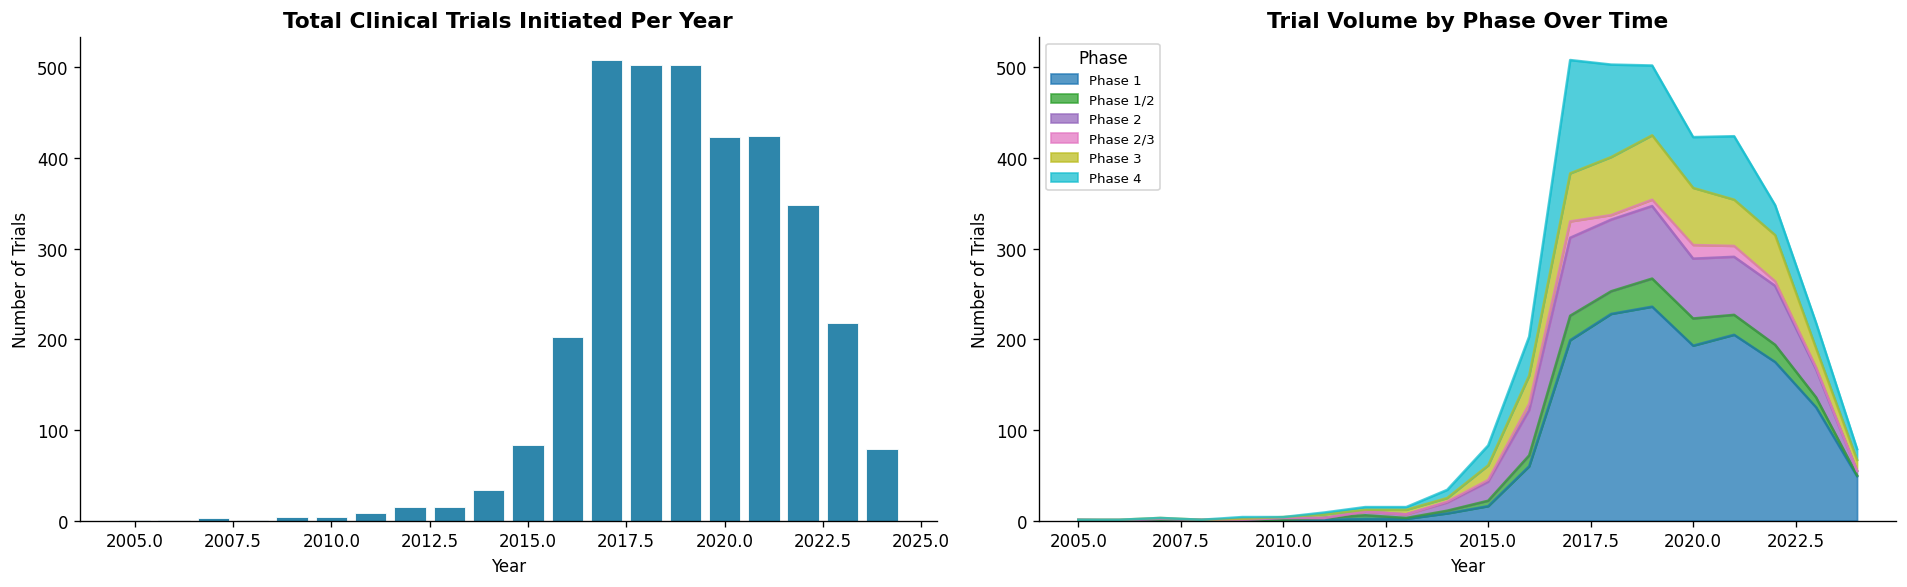

Insight: We observe the impact of COVID-19 era urgency in post-2020 trial surges,
particularly in early-phase and Phase 2 trials, reflecting the industry scrambling
to bring new therapies to market quickly.


In [8]:
yearly_trials = df.groupby("Start_Year").size().reset_index(name="Trial_Count")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# total trial volume by year
axes[0].bar(yearly_trials["Start_Year"], yearly_trials["Trial_Count"],
            color="#2E86AB", edgecolor="white", linewidth=0.5)
axes[0].set_title("Total Clinical Trials Initiated Per Year", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Number of Trials")

# phase-wise trial count over years
phase_year = df.groupby(["Start_Year", "Phase_Clean"]).size().unstack(fill_value=0)
phase_year.plot(kind="area", stacked=True, ax=axes[1], colormap="tab10", alpha=0.75)
axes[1].set_title("Trial Volume by Phase Over Time", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Number of Trials")
axes[1].legend(title="Phase", fontsize=8, loc="upper left")

plt.tight_layout()
plt.savefig("fig_trial_landscape.png", bbox_inches="tight")
plt.show()
print("Insight: We observe the impact of COVID-19 era urgency in post-2020 trial surges,")
print("particularly in early-phase and Phase 2 trials, reflecting the industry scrambling")
print("to bring new therapies to market quickly.")

### 3.2 Enrollment Distribution (The Skewness Problem)
Statistical justification: Enrollment follows a heavy right-skewed distribution (mean is much larger than median). The median of ~52 and mean of ~920 tell us a few mega-trials are pulling the average up. For analysis, we use log-transformed enrollment.

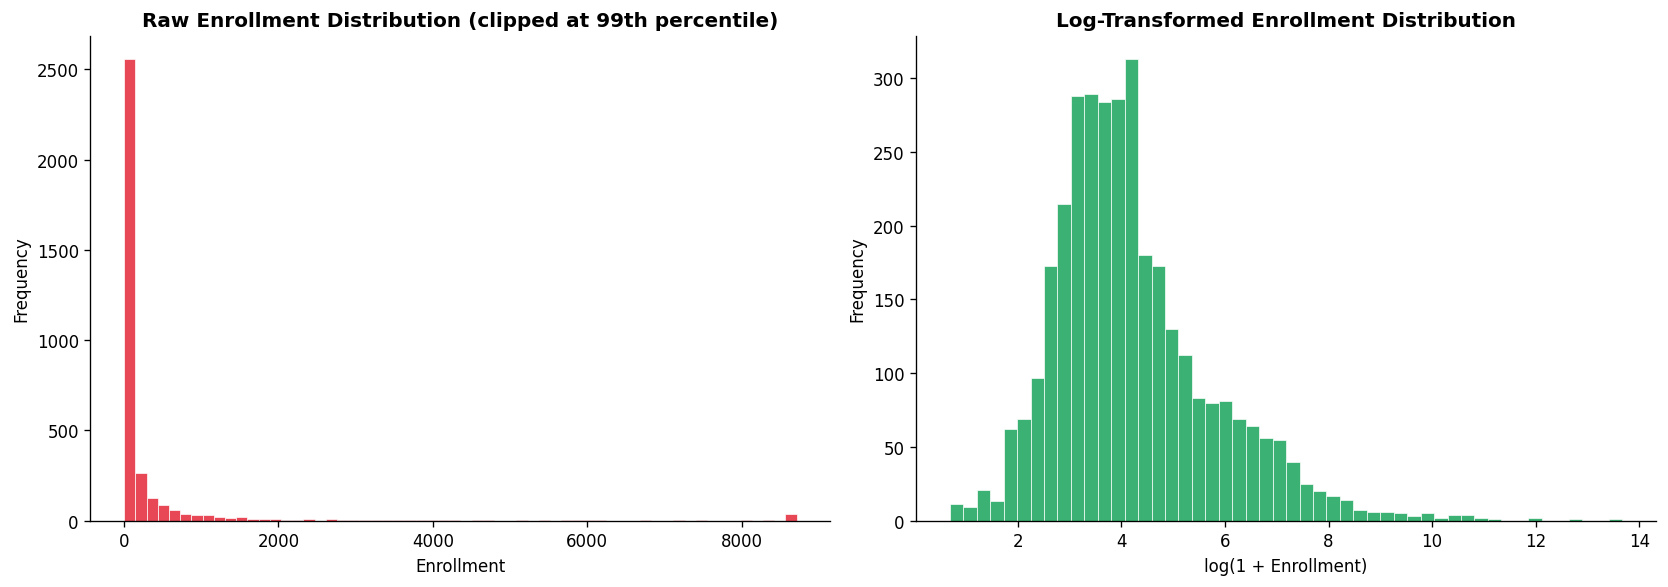

Skewness of raw enrollment: 43.64
Skewness >> 1 confirms strong right skew. Log transform brings it closer to normal.
Skewness after log transform: 1.12


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# raw enrollment
axes[0].hist(df["Enrollment"].clip(upper=df["Enrollment"].quantile(0.99)),
             bins=60, color="#E84855", edgecolor="white", linewidth=0.4)
axes[0].set_title("Raw Enrollment Distribution (clipped at 99th percentile)",
                  fontsize=12, fontweight="bold")
axes[0].set_xlabel("Enrollment")
axes[0].set_ylabel("Frequency")

# log-transformed enrollment
df["Log_Enrollment"] = np.log1p(df["Enrollment"])
axes[1].hist(df["Log_Enrollment"], bins=50, color="#3BB273", edgecolor="white", linewidth=0.4)
axes[1].set_title("Log-Transformed Enrollment Distribution",
                  fontsize=12, fontweight="bold")
axes[1].set_xlabel("log(1 + Enrollment)")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.savefig("fig_enrollment_dist.png", bbox_inches="tight")
plt.show()

skewness = df["Enrollment"].skew()
print(f"Skewness of raw enrollment: {skewness:.2f}")
print("Skewness >> 1 confirms strong right skew. Log transform brings it closer to normal.")
print(f"Skewness after log transform: {df['Log_Enrollment'].skew():.2f}")

### 3.3 Failure Rate by Phase
Business question: Where do trials break down the most? This is the failure funnel.
The clinical pipeline has well-known attrition. Historically, Phase 1 success rates hover around 63%, Phase 2 around 31%, and Phase 3 around 58% (industry benchmarks). 

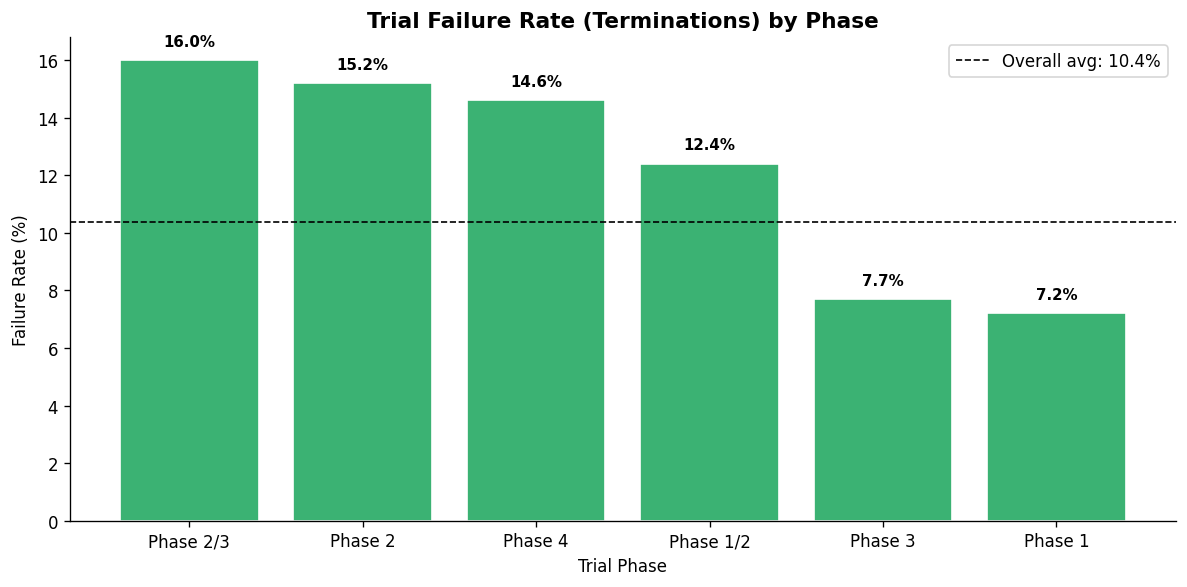

Phase_Clean  Total  Failed  Failure_Rate
  Phase 2/3     75    12.0          16.0
    Phase 2    560    85.0          15.2
    Phase 4    582    85.0          14.6
  Phase 1/2    194    24.0          12.4
    Phase 3    443    34.0           7.7
    Phase 1   1496   107.0           7.2


In [10]:
# restrict to completed or terminated trials only
df_outcome = df[df["Status_Clean"].isin(["Completed", "Terminated"])].copy()

phase_failure = df_outcome.groupby("Phase_Clean")["Is_Failed"].agg(
    Total="count",
    Failed="sum"
).reset_index()
phase_failure["Failure_Rate"] = (phase_failure["Failed"] / phase_failure["Total"] * 100).round(1)
phase_failure = phase_failure.sort_values("Failure_Rate", ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(phase_failure["Phase_Clean"], phase_failure["Failure_Rate"],
              color=["#E84855" if r > 20 else "#3BB273" for r in phase_failure["Failure_Rate"]],
              edgecolor="white")
for bar, rate in zip(bars, phase_failure["Failure_Rate"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            f"{rate}%", ha="center", fontsize=9, fontweight="bold")
ax.set_title("Trial Failure Rate (Terminations) by Phase", fontsize=13, fontweight="bold")
ax.set_xlabel("Trial Phase")
ax.set_ylabel("Failure Rate (%)")
ax.axhline(df_outcome["Is_Failed"].mean() * 100, color="black", linestyle="--",
           linewidth=1, label=f"Overall avg: {df_outcome['Is_Failed'].mean()*100:.1f}%")
ax.legend()
plt.tight_layout()
plt.savefig("fig_failure_by_phase.png", bbox_inches="tight")
plt.show()
print(phase_failure.to_string(index=False))

### 3.4 Top Sponsors: Volume vs Failure Rate
Business question: Which sponsors are most active and which ones have the worst failure records?

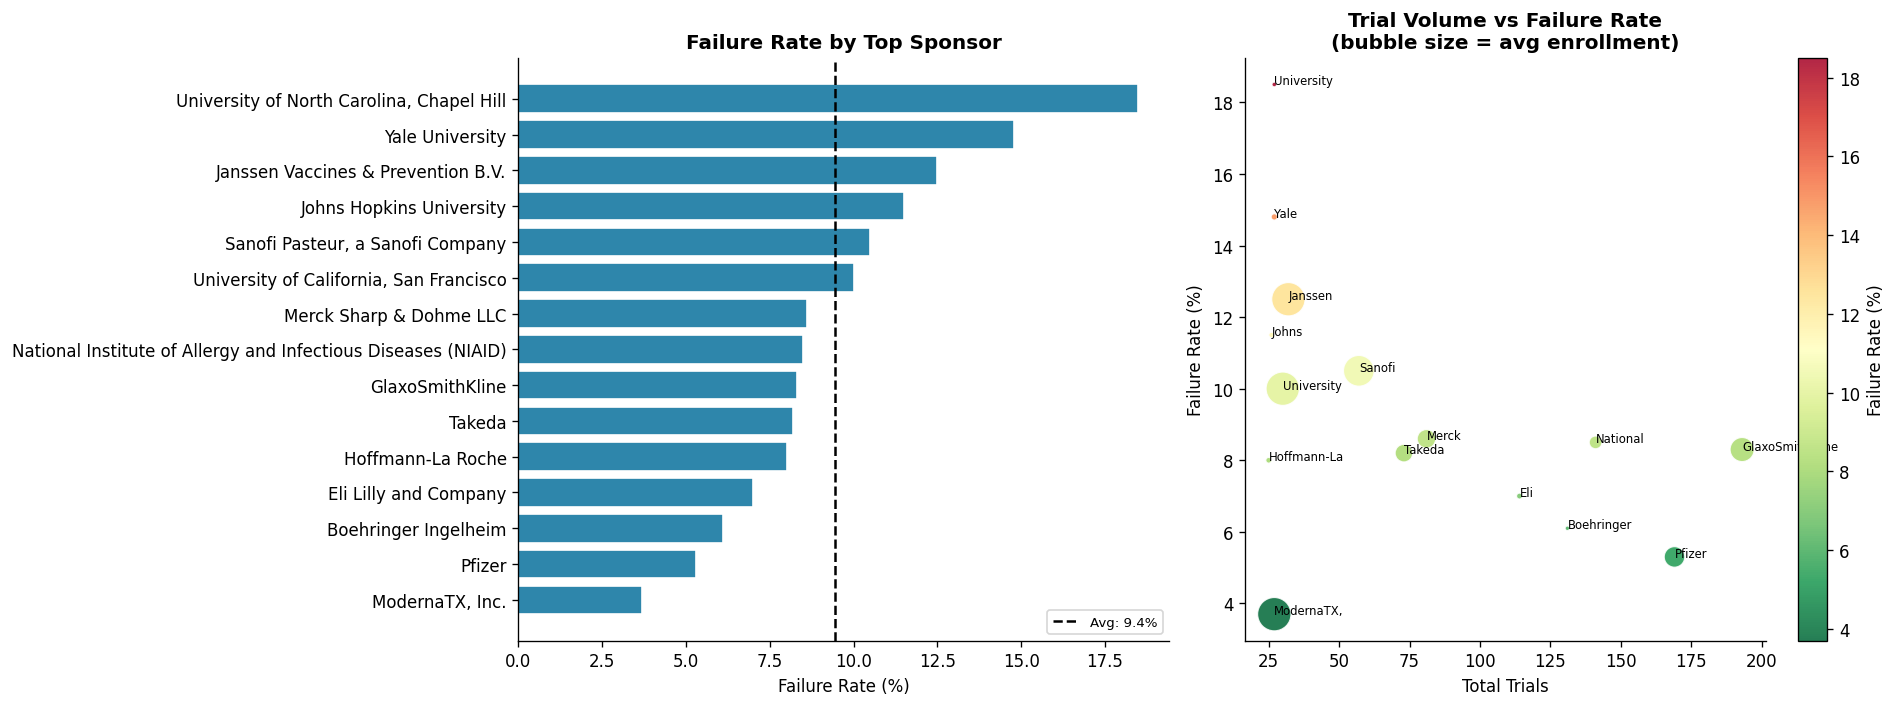

In [11]:
# look at top 15 sponsors by trial count
top_sponsors = df["Sponsor"].value_counts().head(15).index.tolist()
df_top = df[df["Sponsor"].isin(top_sponsors)].copy()

# failure rate by sponsor
sponsor_stats = df_top[df_top["Status_Clean"].isin(["Completed", "Terminated"])].groupby("Sponsor").agg(
    Total_Trials=("Is_Failed", "count"),
    Failed_Trials=("Is_Failed", "sum"),
    Avg_Enrollment=("Enrollment", "mean"),
    Avg_Duration=("Duration_Months", "mean")
).reset_index()
sponsor_stats["Failure_Rate"] = (sponsor_stats["Failed_Trials"] /
                                  sponsor_stats["Total_Trials"] * 100).round(1)
sponsor_stats = sponsor_stats.sort_values("Failure_Rate", ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# failure rate per sponsor
color_map = ["#E84855" if r > 20 else "#2E86AB" for r in sponsor_stats["Failure_Rate"]]
axes[0].barh(sponsor_stats["Sponsor"], sponsor_stats["Failure_Rate"],
             color=color_map, edgecolor="white")
axes[0].set_title("Failure Rate by Top Sponsor", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Failure Rate (%)")
axes[0].axvline(sponsor_stats["Failure_Rate"].mean(), color="black", linestyle="--",
                label=f"Avg: {sponsor_stats['Failure_Rate'].mean():.1f}%")
axes[0].legend(fontsize=8)

# scatter: total trials vs failure rate, sized by avg enrollment
scatter = axes[1].scatter(
    sponsor_stats["Total_Trials"],
    sponsor_stats["Failure_Rate"],
    s=sponsor_stats["Avg_Enrollment"].clip(upper=2000) / 5,
    c=sponsor_stats["Failure_Rate"],
    cmap="RdYlGn_r",
    edgecolors="white",
    linewidth=0.7,
    alpha=0.85
)
for _, row in sponsor_stats.iterrows():
    axes[1].annotate(row["Sponsor"].split()[0], (row["Total_Trials"], row["Failure_Rate"]),
                     fontsize=7, ha="left")
axes[1].set_title("Trial Volume vs Failure Rate\n(bubble size = avg enrollment)",
                  fontsize=12, fontweight="bold")
axes[1].set_xlabel("Total Trials")
axes[1].set_ylabel("Failure Rate (%)")
plt.colorbar(scatter, ax=axes[1], label="Failure Rate (%)")

plt.tight_layout()
plt.savefig("fig_sponsor_landscape.png", bbox_inches="tight")
plt.show()

### 3.5 Medical Domain Growth Trends
Business question: Which therapeutic areas are growing and which are plateauing?

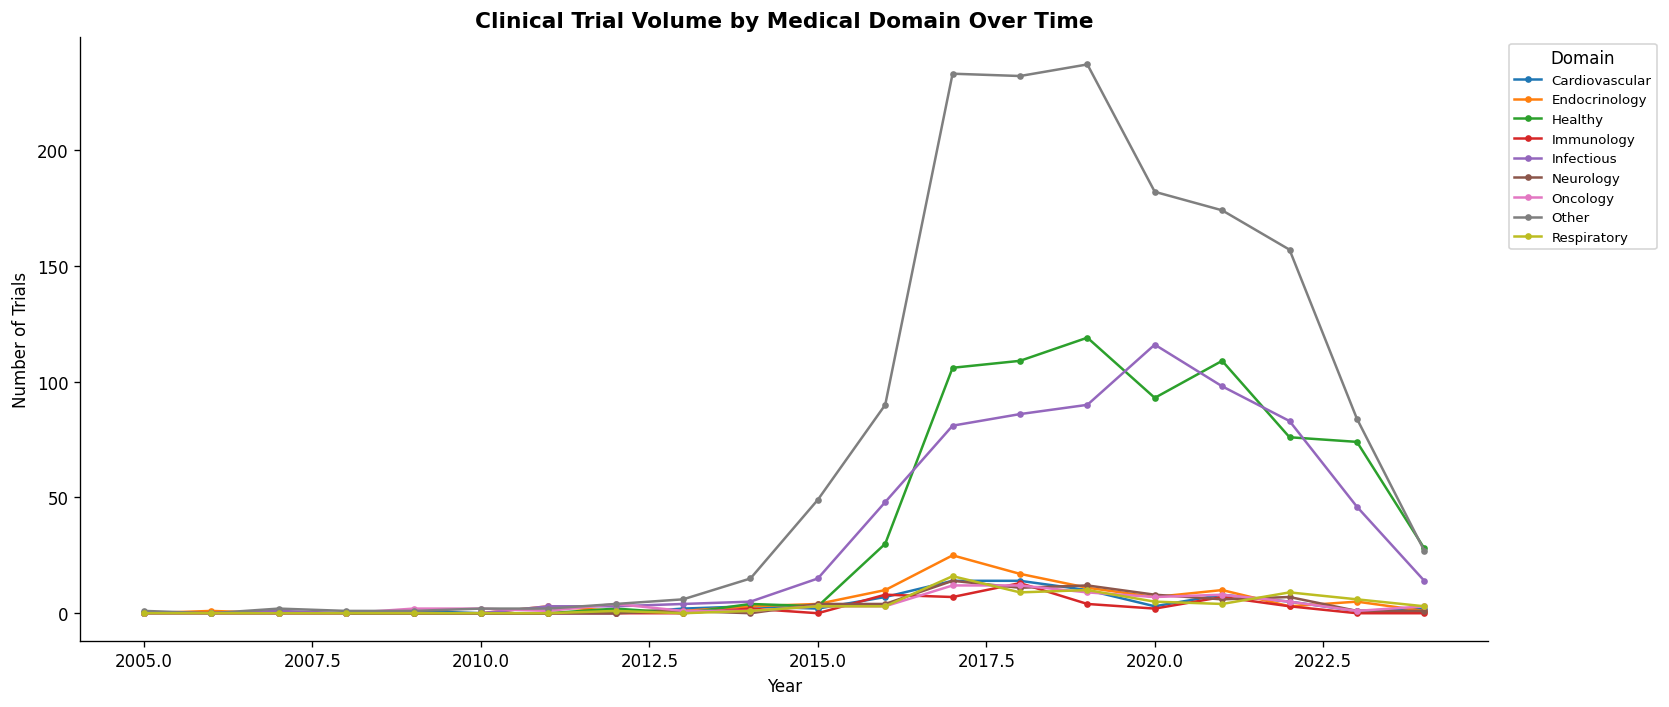

In [12]:
domain_year = df.groupby(["Start_Year", "Medical_Domain"]).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(14, 6))
for col in domain_year.columns:
    ax.plot(domain_year.index, domain_year[col], marker="o", markersize=3,
            linewidth=1.5, label=col)
ax.set_title("Clinical Trial Volume by Medical Domain Over Time", fontsize=13, fontweight="bold")
ax.set_xlabel("Year")
ax.set_ylabel("Number of Trials")
ax.legend(title="Domain", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.savefig("fig_domain_trends.png", bbox_inches="tight")
plt.show()

### 3.6 Enrollment Trends by Domain

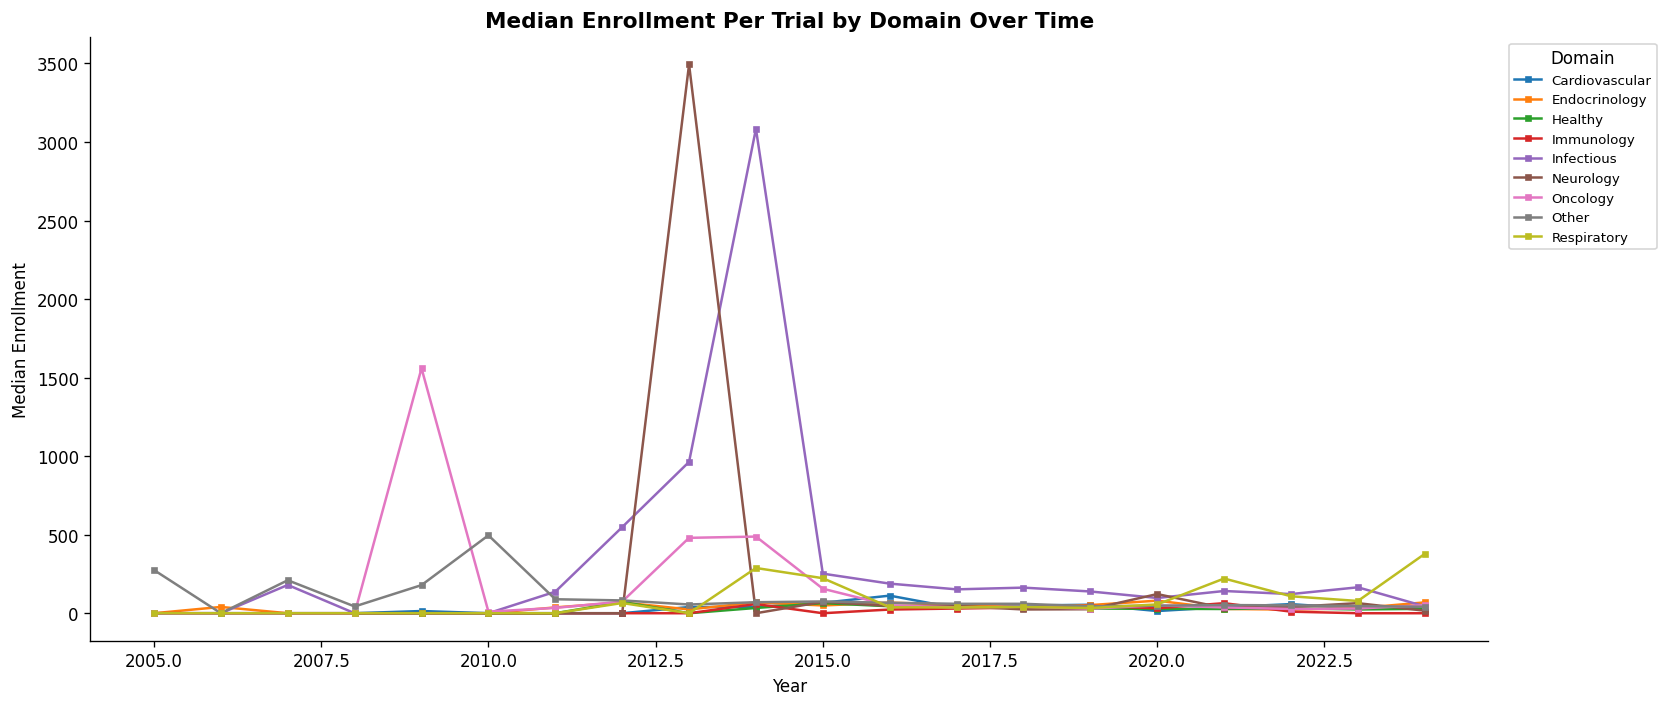

In [13]:
domain_enrollment = df.groupby(["Start_Year", "Medical_Domain"])["Enrollment"].median().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(14, 6))
for col in domain_enrollment.columns:
    ax.plot(domain_enrollment.index, domain_enrollment[col], linewidth=1.5,
            marker="s", markersize=3, label=col)
ax.set_title("Median Enrollment Per Trial by Domain Over Time", fontsize=13, fontweight="bold")
ax.set_xlabel("Year")
ax.set_ylabel("Median Enrollment")
ax.legend(title="Domain", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.savefig("fig_domain_enrollment.png", bbox_inches="tight")
plt.show()

### 3.7 Correlation Heatmap of Numeric Features

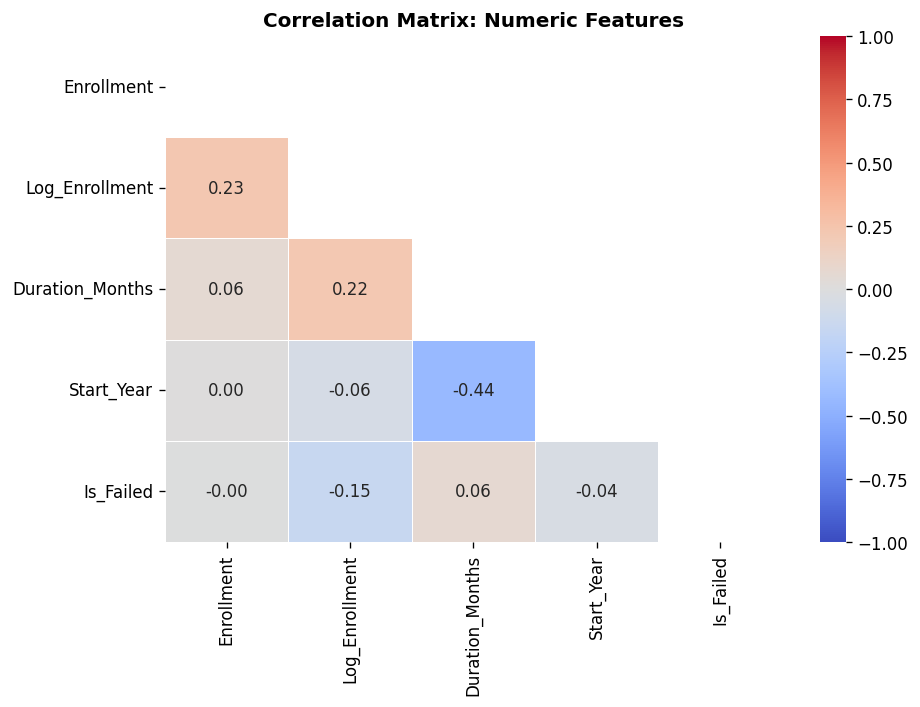

Pearson correlation between Duration and Log_Enrollment: 0.222


In [14]:
numeric_cols = ["Enrollment", "Log_Enrollment", "Duration_Months", "Start_Year", "Is_Failed"]
corr = df[numeric_cols].dropna().corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", mask=mask,
            ax=ax, linewidths=0.5, vmin=-1, vmax=1)
ax.set_title("Correlation Matrix: Numeric Features", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("fig_correlation.png", bbox_inches="tight")
plt.show()
print("Pearson correlation between Duration and Log_Enrollment:",
      corr.loc["Duration_Months", "Log_Enrollment"].round(3))

### 4: Feature Engineering
This is where we translate domain knowledge into numbers that a machine learning model can use.
Why feature engineering matters: Raw columns like "Sponsor" or "Phase" are not useful to a model in string form. We need to encode them, derive new signals, and scale them properly.

In [15]:
# create a fresh modelling dataframe
df_model = df.copy()

# phase numeric rank (reflects trial maturity and cost)
phase_rank = {
    "Phase 1":   1,
    "Phase 1/2": 1.5,
    "Phase 2":   2,
    "Phase 2/3": 2.5,
    "Phase 3":   3,
    "Phase 4":   4,
    "Unknown":   0
}
df_model["Phase_Rank"] = df_model["Phase_Clean"].map(phase_rank)

# sponsor size proxy: number of trials a sponsor has run (larger = more established)
sponsor_trial_counts = df_model["Sponsor"].value_counts()
df_model["Sponsor_Size"] = df_model["Sponsor"].map(sponsor_trial_counts)

# sponsor failure history ratio (lagged / external knowledge signal)
# computed as: for each trial, what fraction of the sponsor's OTHER trials failed
sponsor_fail_rate = (
    df_model[df_model["Is_Failed"].notna()]
    .groupby("Sponsor")["Is_Failed"].mean()
)
df_model["Sponsor_Hist_Fail_Rate"] = df_model["Sponsor"].map(sponsor_fail_rate).fillna(
    df_model["Is_Failed"].mean()
)

# funder type encoding: industry funding often means more resources
funder_rank = {
    "INDUSTRY": 3,
    "NIH":      2,
    "FED":      2,
    "OTHER_GOV":2,
    "NETWORK":  1,
    "OTHER":    1,
    "UNKNOWN":  0,
    "INDIV":    0
}
df_model["Funder_Rank"] = df_model["Funder Type"].map(funder_rank).fillna(0)

# masking type numeric (higher masking = more rigorous design = often phase 3)
masking_rank = {"NONE": 0, "SINGLE": 1, "DOUBLE": 2, "TRIPLE": 3, "QUADRUPLE": 4}
df_model["Masking_Rank"] = df_model["Masking_Type"].map(masking_rank).fillna(0)

# randomization flag
df_model["Is_Randomized"] = (df_model["Allocation_Type"] == "RANDOMIZED").astype(int)

# intervention type encoding
le_intervention = LabelEncoder()
df_model["Intervention_Code"] = le_intervention.fit_transform(
    df_model["Intervention_Type"].fillna("OTHER")
)

# medical domain encoding
le_domain = LabelEncoder()
df_model["Domain_Code"] = le_domain.fit_transform(
    df_model["Medical_Domain"].fillna("Other")
)

# years since 2005 (time trend feature)
df_model["Years_Since_2005"] = df_model["Start_Year"] - 2005

print("Feature engineering complete.")
print("New features added:")
new_features = ["Phase_Rank", "Sponsor_Size", "Sponsor_Hist_Fail_Rate",
                "Funder_Rank", "Masking_Rank", "Is_Randomized",
                "Intervention_Code", "Domain_Code", "Years_Since_2005"]
for f in new_features:
    print(f"  - {f}: {df_model[f].dtype}, range [{df_model[f].min():.2f}, {df_model[f].max():.2f}]")

Feature engineering complete.
New features added:
  - Phase_Rank: float64, range [1.00, 4.00]
  - Sponsor_Size: int64, range [1.00, 194.00]
  - Sponsor_Hist_Fail_Rate: float64, range [0.00, 1.00]
  - Funder_Rank: int64, range [0.00, 3.00]
  - Masking_Rank: int64, range [0.00, 4.00]
  - Is_Randomized: int64, range [0.00, 1.00]
  - Intervention_Code: int64, range [0.00, 6.00]
  - Domain_Code: int64, range [0.00, 8.00]
  - Years_Since_2005: int32, range [0.00, 19.00]


### 4.1 Feature Scaling
Why we scale: Machine learning models like Logistic Regression use gradient-based optimisation. If one feature ranges from 0 to 864,000 (enrollment) and another from 0 to 4 (phase rank), the large-scale feature dominates gradients artificially.

- We use StandardScaler, which transforms each feature to have mean = 0 and standard deviation = 1:

- **z = (x - mean) / std**

- Tree-based models (Random Forest, Gradient Boosting) do not need scaling because they use splits, not distances. We scale only for the logistic regression model.

In [16]:
FEATURE_COLS = [
    "Phase_Rank", "Log_Enrollment", "Duration_Months",
    "Sponsor_Size", "Sponsor_Hist_Fail_Rate", "Funder_Rank",
    "Masking_Rank", "Is_Randomized", "Intervention_Code",
    "Domain_Code", "Years_Since_2005"
]

TARGET_COL = "Is_Failed"

# restrict to rows with known outcome
df_ml = df_model[df_model[TARGET_COL].notna()][FEATURE_COLS + [TARGET_COL]].dropna()
print(f"Modelling dataset size: {df_ml.shape[0]} rows")

X = df_ml[FEATURE_COLS].values
y = df_ml[TARGET_COL].values.astype(int)

print(f"Class balance - Completed (0): {(y==0).sum()}, Terminated (1): {(y==1).sum()}")
print(f"Failure rate in model dataset: {y.mean()*100:.1f}%")

Modelling dataset size: 3350 rows
Class balance - Completed (0): 3003, Terminated (1): 347
Failure rate in model dataset: 10.4%


### 5: Machine Learning - Predicting Trial Failure
### 5.1 The Business Problem as a Machine Learning Task
We are framing this as a binary classification problem:

- **Target:** Will this trial be terminated (failure = 1) or completed (success = 0)?
- **Why this matters:** A sponsor investing in a Phase 3 oncology trial could be spending upwards of $100 million. A model that flags high-risk trials early allows reallocation of R&D budget before resources are burned.

### 5.2 Train-Test Split
We use an 80/20 stratified split. Stratification ensures that the proportion of failures is the same in both the training and test sets, which is important because failure events are a minority class.

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y  # preserves class proportions
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set:     {X_test.shape[0]} samples")
print(f"Train failure rate: {y_train.mean()*100:.1f}%")
print(f"Test failure rate:  {y_test.mean()*100:.1f}%")

Training set: 2680 samples
Test set:     670 samples
Train failure rate: 10.4%
Test failure rate:  10.3%


### 5.3 Training Three Models
We train three models with different inductive biases and compare them. This is a model selection exercise.
### Model 1: Logistic Regression
The simplest linear classifier. It models the log-odds of failure as a linear combination of features:

- **log(P/(1-P)) = b0 + b1x1 + b2x2 + ... + bn*xn**

- It gives us interpretable coefficients. A positive coefficient for Phase_Rank means higher phases have higher odds of failure.

### Model 2: Random Forest
An ensemble of decision trees. Each tree is built on a random subset of data and features, and predictions are averaged. It captures non-linear interactions between features without requiring scaling.

### Model 3: Gradient Boosting
Builds trees sequentially, with each tree correcting the errors of the previous one. It often outperforms Random Forest on structured tabular data.

In [18]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# model 1: logistic regression (needs scaled input)
lr = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
lr.fit(X_train_scaled, y_train)

# model 2: random forest (does not need scaling)
rf = RandomForestClassifier(n_estimators=200, max_depth=8, class_weight="balanced",
                             random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

# model 3: gradient boosting
gb = GradientBoostingClassifier(n_estimators=200, max_depth=4, learning_rate=0.05,
                                 random_state=42)
gb.fit(X_train, y_train)

print("All three models trained.")

All three models trained.


### 5.4 Model Evaluation
We evaluate models using multiple metrics because a single number never tells the whole story.
Why accuracy alone is misleading: If 85% of trials complete, a model that always predicts "no failure" gets 85% accuracy but catches zero failures. That is useless for risk management.



- **ROC-AUC:** Area under the receiver operating curve. Measures how well the model ranks positives above negatives across all thresholds. 1.0 is perfect, 0.5 is random.
- **Recall (Sensitivity):** Of all actual failures, how many did we catch? Critical in healthcare where missing a failure is costly.
- **Precision:** Of all predicted failures, how many were real? Controls for false alarms.
- **F1 Score:** Harmonic mean of precision and recall. Balances both.

In [19]:
models = {
    "Logistic Regression": (lr, X_test_scaled),
    "Random Forest":       (rf, X_test),
    "Gradient Boosting":   (gb, X_test)
}

results = {}
for name, (model, Xtest) in models.items():
    y_pred  = model.predict(Xtest)
    y_proba = model.predict_proba(Xtest)[:, 1]
    auc = roc_auc_score(y_test, y_proba)
    report = classification_report(y_test, y_pred, output_dict=True)
    results[name] = {
        "AUC":       auc,
        "Precision": report["1"]["precision"],
        "Recall":    report["1"]["recall"],
        "F1":        report["1"]["f1-score"],
        "Accuracy":  report["accuracy"]
    }
    print(f"\n{name}")
    print(f"  AUC-ROC:   {auc:.3f}")
    print(f"  Accuracy:  {report['accuracy']:.3f}")
    print(f"  Precision: {report['1']['precision']:.3f}")
    print(f"  Recall:    {report['1']['recall']:.3f}")
    print(f"  F1-Score:  {report['1']['f1-score']:.3f}")

results_df = pd.DataFrame(results).T.round(3)
print("\nModel Comparison Summary:")
print(results_df)


Logistic Regression
  AUC-ROC:   0.857
  Accuracy:  0.851
  Precision: 0.370
  Recall:    0.638
  F1-Score:  0.468

Random Forest
  AUC-ROC:   0.857
  Accuracy:  0.903
  Precision: 0.530
  Recall:    0.507
  F1-Score:  0.519

Gradient Boosting
  AUC-ROC:   0.878
  Accuracy:  0.924
  Precision: 0.846
  Recall:    0.319
  F1-Score:  0.463

Model Comparison Summary:
                       AUC  Precision  Recall     F1  Accuracy
Logistic Regression  0.857      0.370   0.638  0.468     0.851
Random Forest        0.857      0.530   0.507  0.519     0.903
Gradient Boosting    0.878      0.846   0.319  0.463     0.924


### 5.5 Visual Evaluation

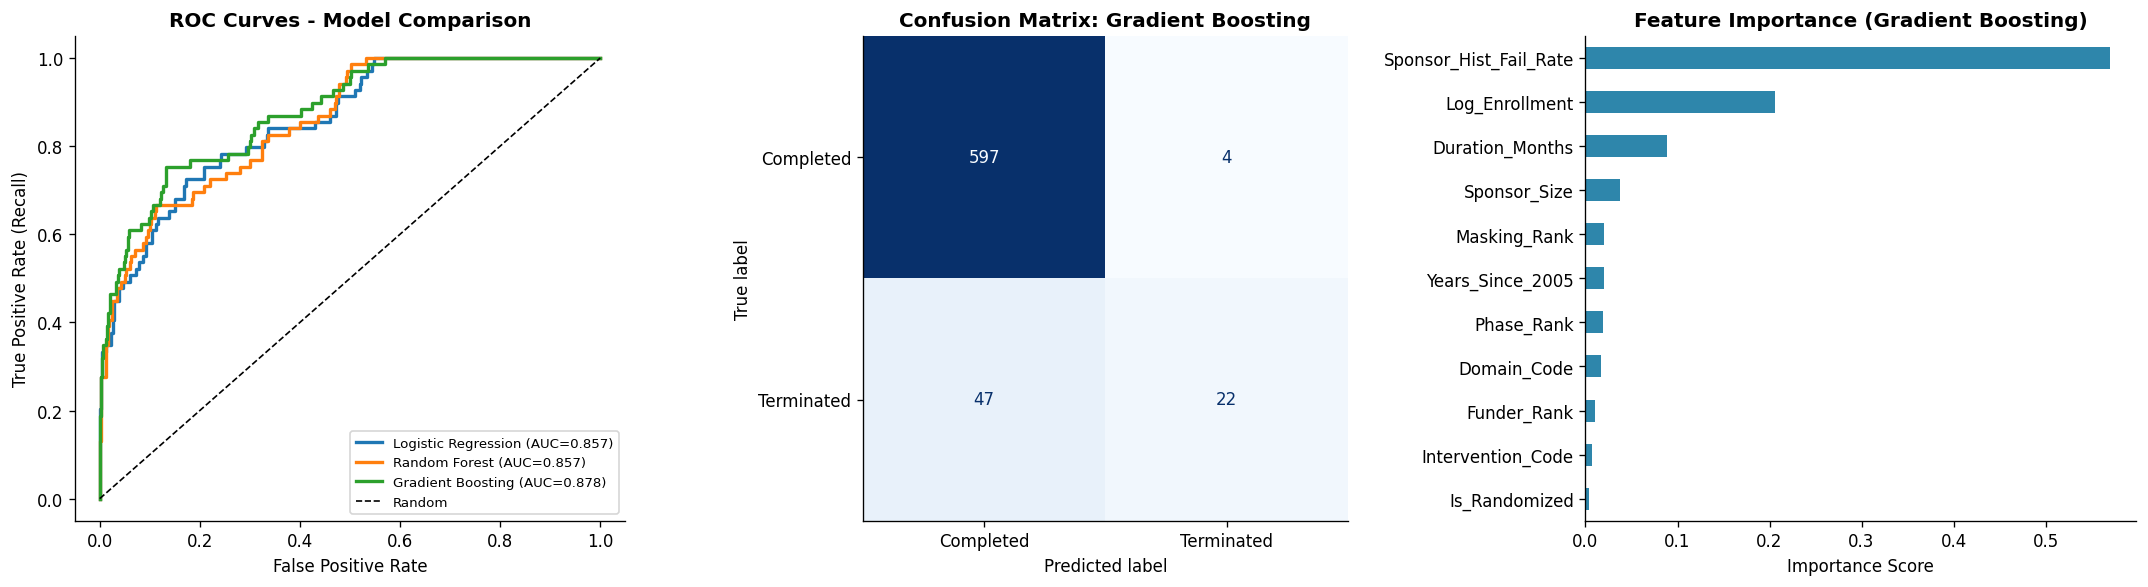


Best model selected: Gradient Boosting
Selection criterion: Highest ROC-AUC score on held-out test set.
AUC is preferred over accuracy because our dataset has class imbalance.


In [20]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# roc curves for all models
for name, (model, Xtest) in models.items():
    y_proba = model.predict_proba(Xtest)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = results[name]["AUC"]
    axes[0].plot(fpr, tpr, linewidth=2, label=f"{name} (AUC={auc:.3f})")
axes[0].plot([0, 1], [0, 1], "k--", linewidth=1, label="Random")
axes[0].set_title("ROC Curves - Model Comparison", fontsize=12, fontweight="bold")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate (Recall)")
axes[0].legend(fontsize=8)

# confusion matrix for best model (gradient boosting)
best_model_name = max(results, key=lambda k: results[k]["AUC"])
best_model, best_X = models[best_model_name]
y_pred_best = best_model.predict(best_X)
cm = confusion_matrix(y_test, y_pred_best)
ConfusionMatrixDisplay(cm, display_labels=["Completed", "Terminated"]).plot(
    ax=axes[1], colorbar=False, cmap="Blues"
)
axes[1].set_title(f"Confusion Matrix: {best_model_name}", fontsize=12, fontweight="bold")

# feature importance (from random forest or gradient boosting)
best_tree_model = gb
importances = best_tree_model.feature_importances_
feat_imp = pd.Series(importances, index=FEATURE_COLS).sort_values(ascending=True)
feat_imp.plot(kind="barh", ax=axes[2], color="#2E86AB")
axes[2].set_title("Feature Importance (Gradient Boosting)", fontsize=12, fontweight="bold")
axes[2].set_xlabel("Importance Score")

plt.tight_layout()
plt.savefig("fig_model_evaluation.png", bbox_inches="tight")
plt.show()

print(f"\nBest model selected: {best_model_name}")
print("Selection criterion: Highest ROC-AUC score on held-out test set.")
print("AUC is preferred over accuracy because our dataset has class imbalance.")

### 6: Time Series Analysis and Forecasting
### 6.1 Trial Volume Forecasting
We use a simple exponential moving average (EMA) for trend smoothing and then fit a linear regression over time to forecast the next 20 years. For a fresher-level approach, think of EMA as a "smoothed" version of the line that gives more weight to recent data points.
- Mathematically: EMA_t = alpha * Y_t + (1 - alpha) * EMA_{t-1}
- For forecasting, we fit: Y = a + b*t where t is years since 2005.

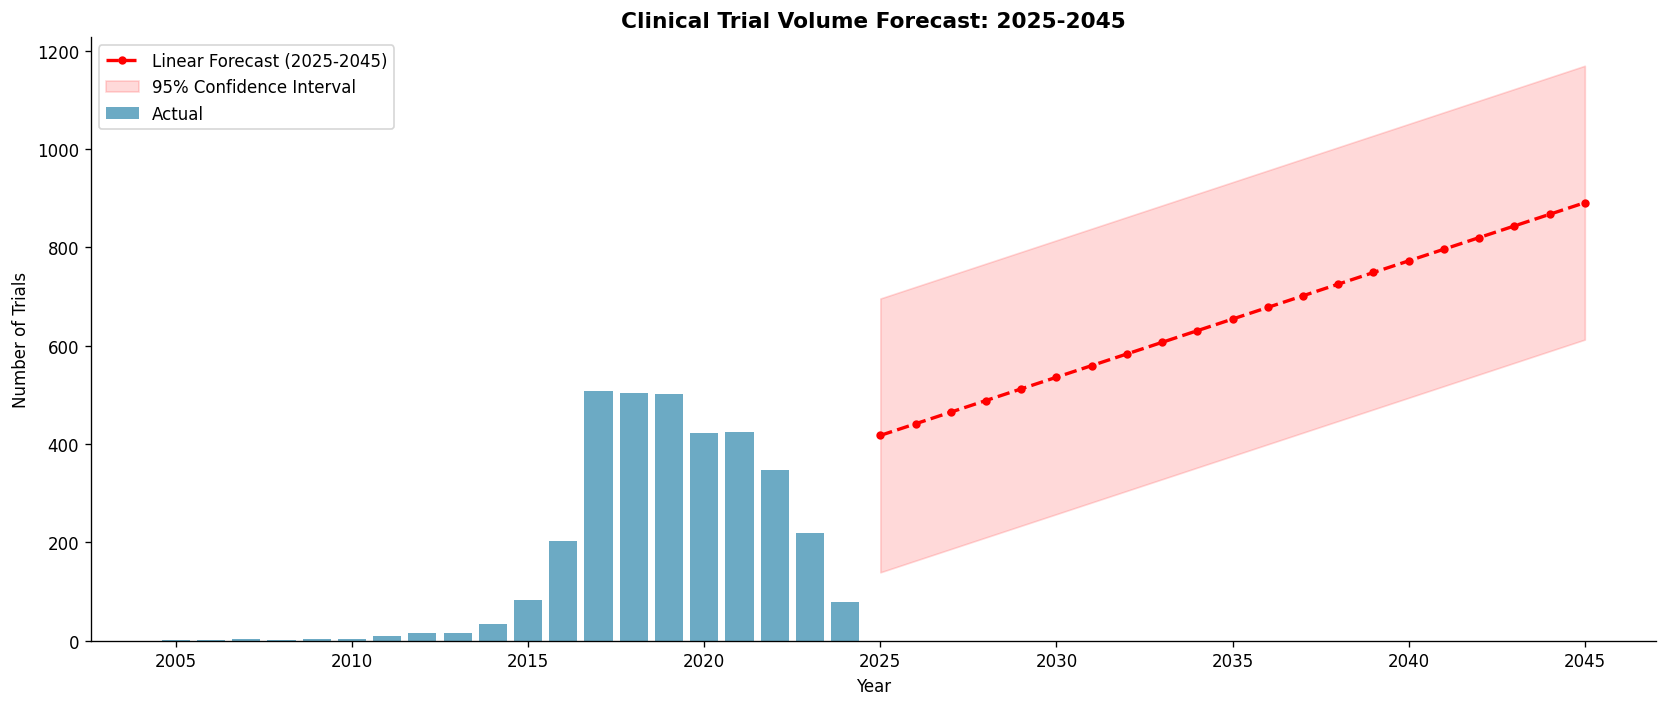

Trend slope: 23.7 additional trials per year
This means the industry is adding approximately 24 new trials per year.


In [21]:
from sklearn.linear_model import LinearRegression

# aggregate trial counts per year
yearly = df.groupby("Start_Year").size().reset_index(name="Count")
yearly = yearly[yearly["Start_Year"] <= 2024].copy()

# fit linear regression for overall trend
t = yearly["Start_Year"].values.reshape(-1, 1)
y_count = yearly["Count"].values
lr_trend = LinearRegression().fit(t, y_count)

# predict 2025 to 2045
future_years = np.arange(2025, 2046).reshape(-1, 1)
future_preds = lr_trend.predict(future_years)
future_preds = np.maximum(future_preds, 0)  # floor at zero

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(yearly["Start_Year"], yearly["Count"], color="#2E86AB", alpha=0.7, label="Actual")
ax.plot(future_years.flatten(), future_preds, "r--", linewidth=2,
        marker="o", markersize=4, label="Linear Forecast (2025-2045)")

# 95% confidence interval (simplified as +-1.96*residual_std)
residuals = y_count - lr_trend.predict(t)
std_error = residuals.std()
ax.fill_between(future_years.flatten(),
                future_preds - 1.96 * std_error,
                future_preds + 1.96 * std_error,
                alpha=0.15, color="red", label="95% Confidence Interval")
ax.set_title("Clinical Trial Volume Forecast: 2025-2045",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Year")
ax.set_ylabel("Number of Trials")
ax.legend()
plt.tight_layout()
plt.savefig("fig_forecast_volume.png", bbox_inches="tight")
plt.show()

slope = lr_trend.coef_[0]
print(f"Trend slope: {slope:.1f} additional trials per year")
print("This means the industry is adding approximately {:.0f} new trials per year.".format(slope))

### 6.2 Enrollment Trend Forecasting by Domain

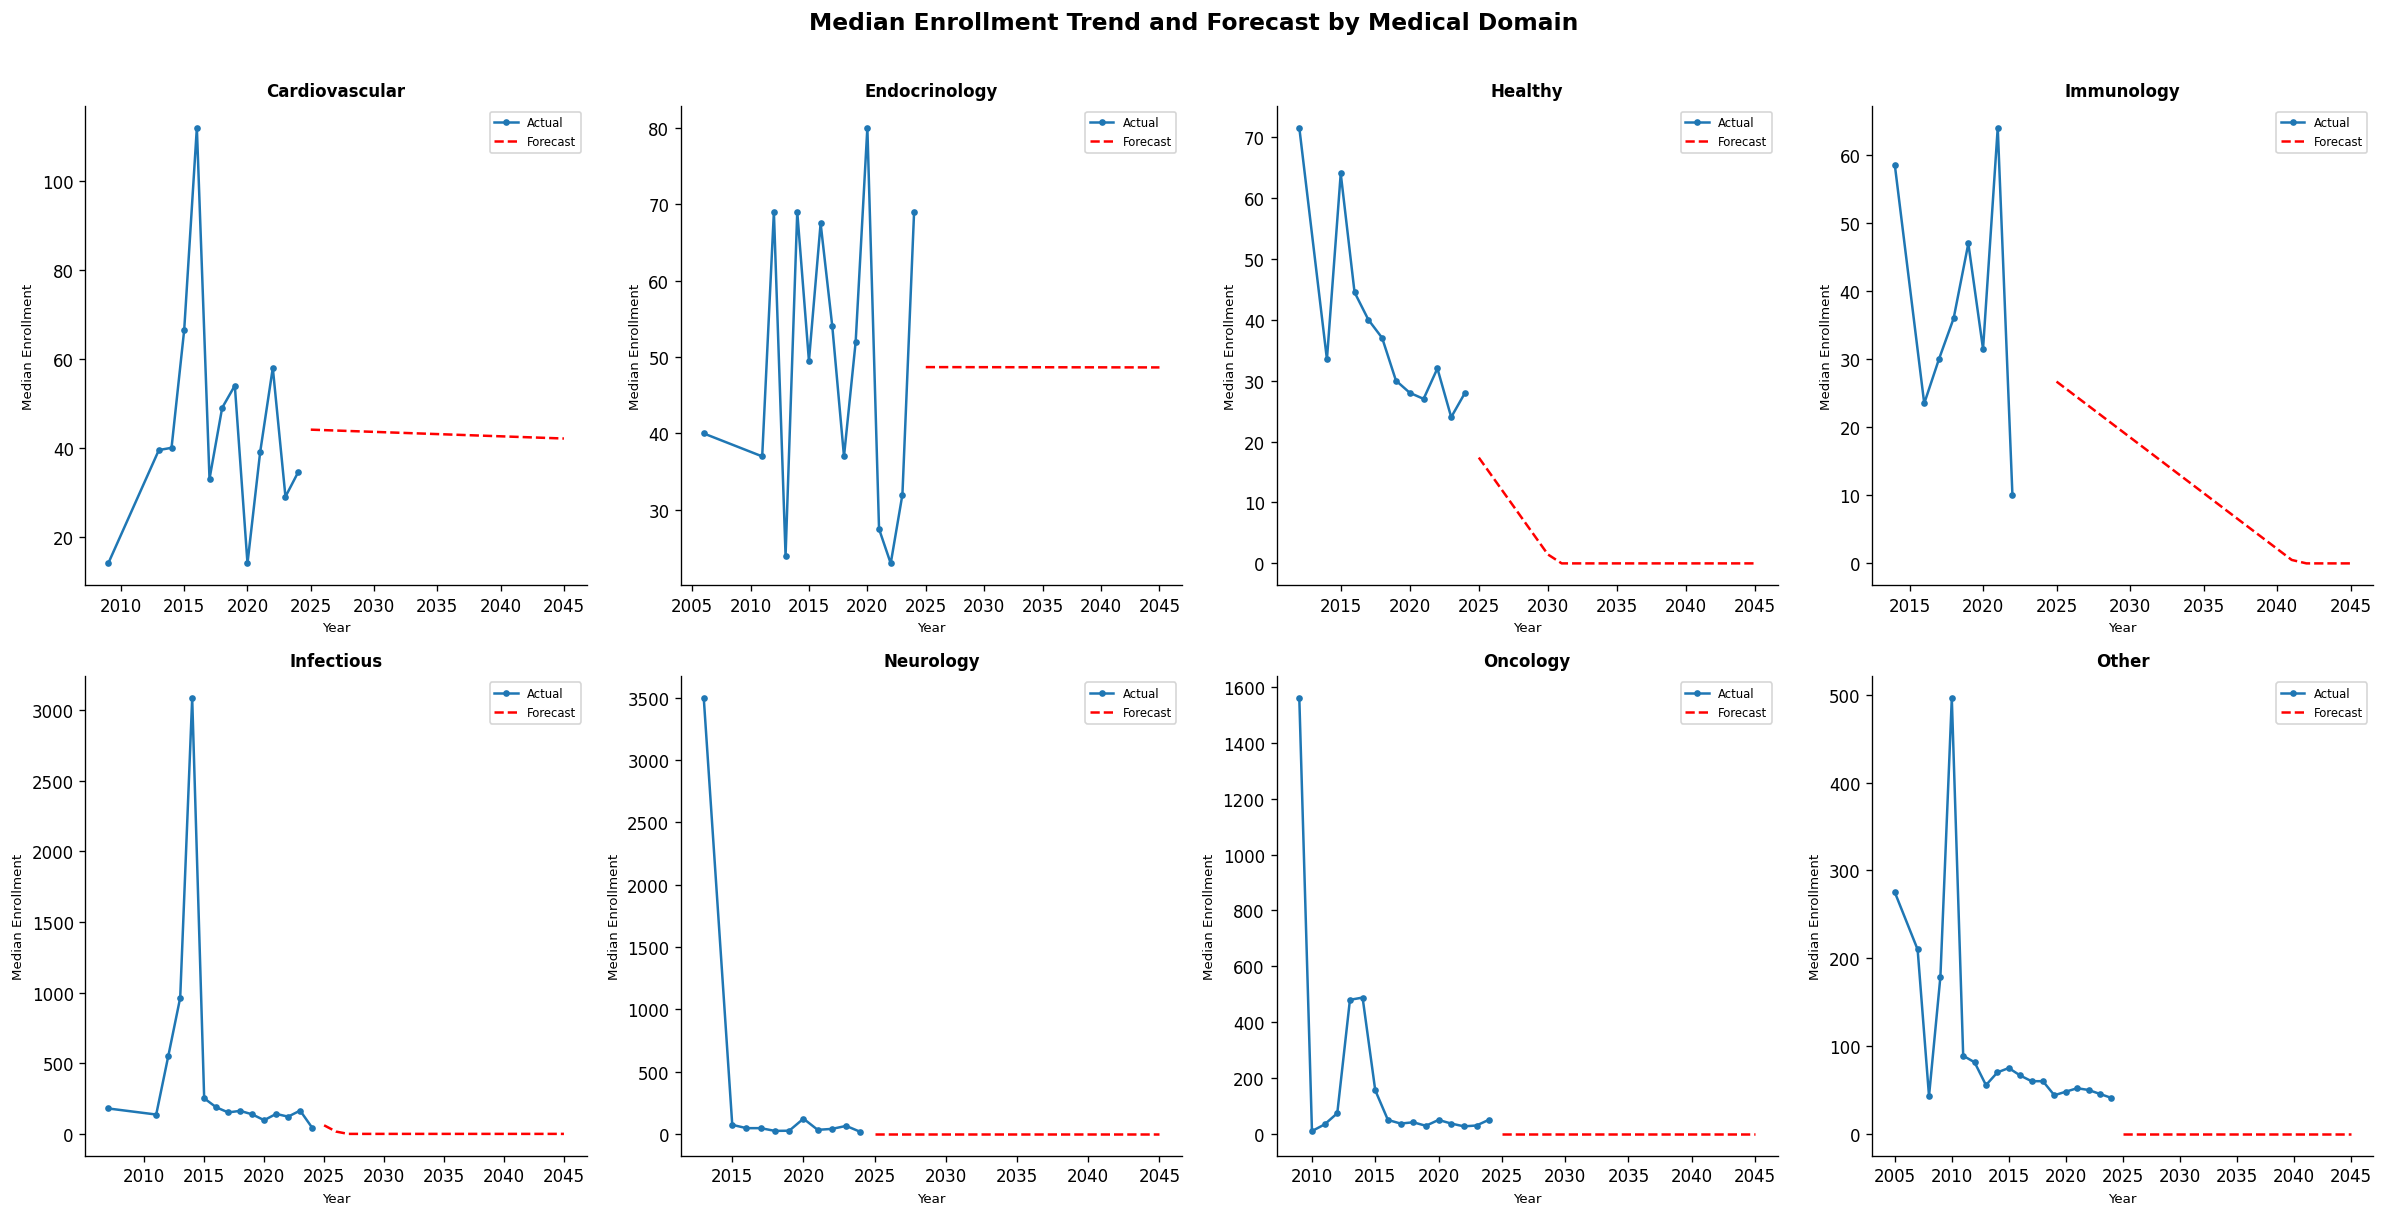

In [22]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()
domains = df["Medical_Domain"].unique()

for idx, domain in enumerate(sorted(domains)):
    if idx >= 8:
        break
    ax = axes[idx]
    domain_data = df[df["Medical_Domain"] == domain].groupby("Start_Year")["Enrollment"].median().reset_index()
    domain_data = domain_data[domain_data["Start_Year"] <= 2024]

    if len(domain_data) < 4:
        ax.set_title(domain, fontsize=9)
        ax.text(0.5, 0.5, "Insufficient data", ha="center", va="center", transform=ax.transAxes)
        continue

    t_ = domain_data["Start_Year"].values.reshape(-1, 1)
    y_ = domain_data["Enrollment"].values
    lr_ = LinearRegression().fit(t_, y_)
    f_years = np.arange(2025, 2046).reshape(-1, 1)
    f_preds = np.maximum(lr_.predict(f_years), 0)

    ax.plot(domain_data["Start_Year"], domain_data["Enrollment"],
            "o-", linewidth=1.5, markersize=3, label="Actual")
    ax.plot(f_years.flatten(), f_preds, "r--", linewidth=1.5, label="Forecast")
    ax.set_title(domain, fontsize=10, fontweight="bold")
    ax.set_xlabel("Year", fontsize=8)
    ax.set_ylabel("Median Enrollment", fontsize=8)
    ax.legend(fontsize=7)

plt.suptitle("Median Enrollment Trend and Forecast by Medical Domain",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("fig_domain_enrollment_forecast.png", bbox_inches="tight")
plt.show()

### 6.3 Detecting "Blooming" Domains
Statistical method: We compute the compound annual growth rate (CAGR) of trial count per domain. 
- CAGR = (End_Value / Start_Value)^(1/years) - 1. 

- Domains with the highest CAGR are the ones that are growing fastest.

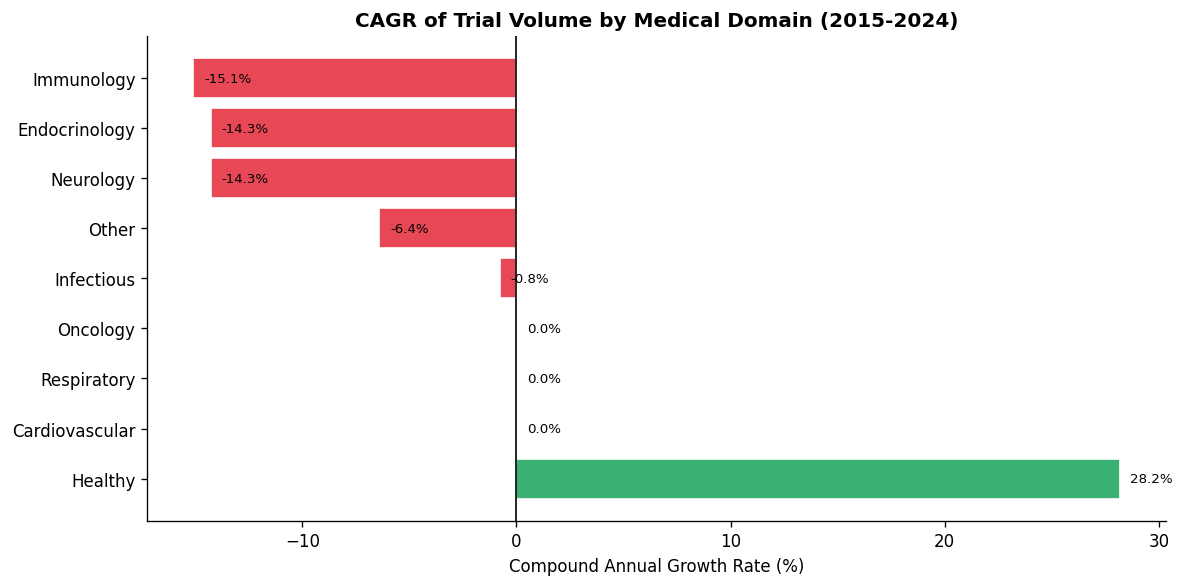

        Domain       CAGR  2024_Trials
       Healthy  28.168666           28
Cardiovascular   0.000000            2
   Respiratory   0.000000            3
      Oncology   0.000000            3
    Infectious  -0.763657           14
         Other  -6.407542           27
     Neurology -14.275602            1
 Endocrinology -14.275602            1
    Immunology -15.080934            3


In [23]:
domain_growth = []
for domain in df["Medical_Domain"].unique():
    d = df[df["Medical_Domain"] == domain].groupby("Start_Year").size()
    d = d[d.index.isin(range(2015, 2025))]
    if len(d) >= 3 and d.iloc[0] > 0:
        cagr = (d.iloc[-1] / d.iloc[0]) ** (1 / max(len(d)-1, 1)) - 1
        domain_growth.append({"Domain": domain, "CAGR": cagr * 100,
                               "2024_Trials": d.get(2024, d.iloc[-1])})

domain_growth_df = pd.DataFrame(domain_growth).sort_values("CAGR", ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
colors = ["#3BB273" if c > 0 else "#E84855" for c in domain_growth_df["CAGR"]]
bars = ax.barh(domain_growth_df["Domain"], domain_growth_df["CAGR"],
               color=colors, edgecolor="white")
ax.axvline(0, color="black", linewidth=1)
ax.set_title("CAGR of Trial Volume by Medical Domain (2015-2024)",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Compound Annual Growth Rate (%)")
for bar, val in zip(bars, domain_growth_df["CAGR"]):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,
            f"{val:.1f}%", va="center", fontsize=8)
plt.tight_layout()
plt.savefig("fig_domain_cagr.png", bbox_inches="tight")
plt.show()
print(domain_growth_df.to_string(index=False))

### 7: Competitive Landscaping Dashboard
This is the collective overview dashboard, showing the entire industry at a glance.

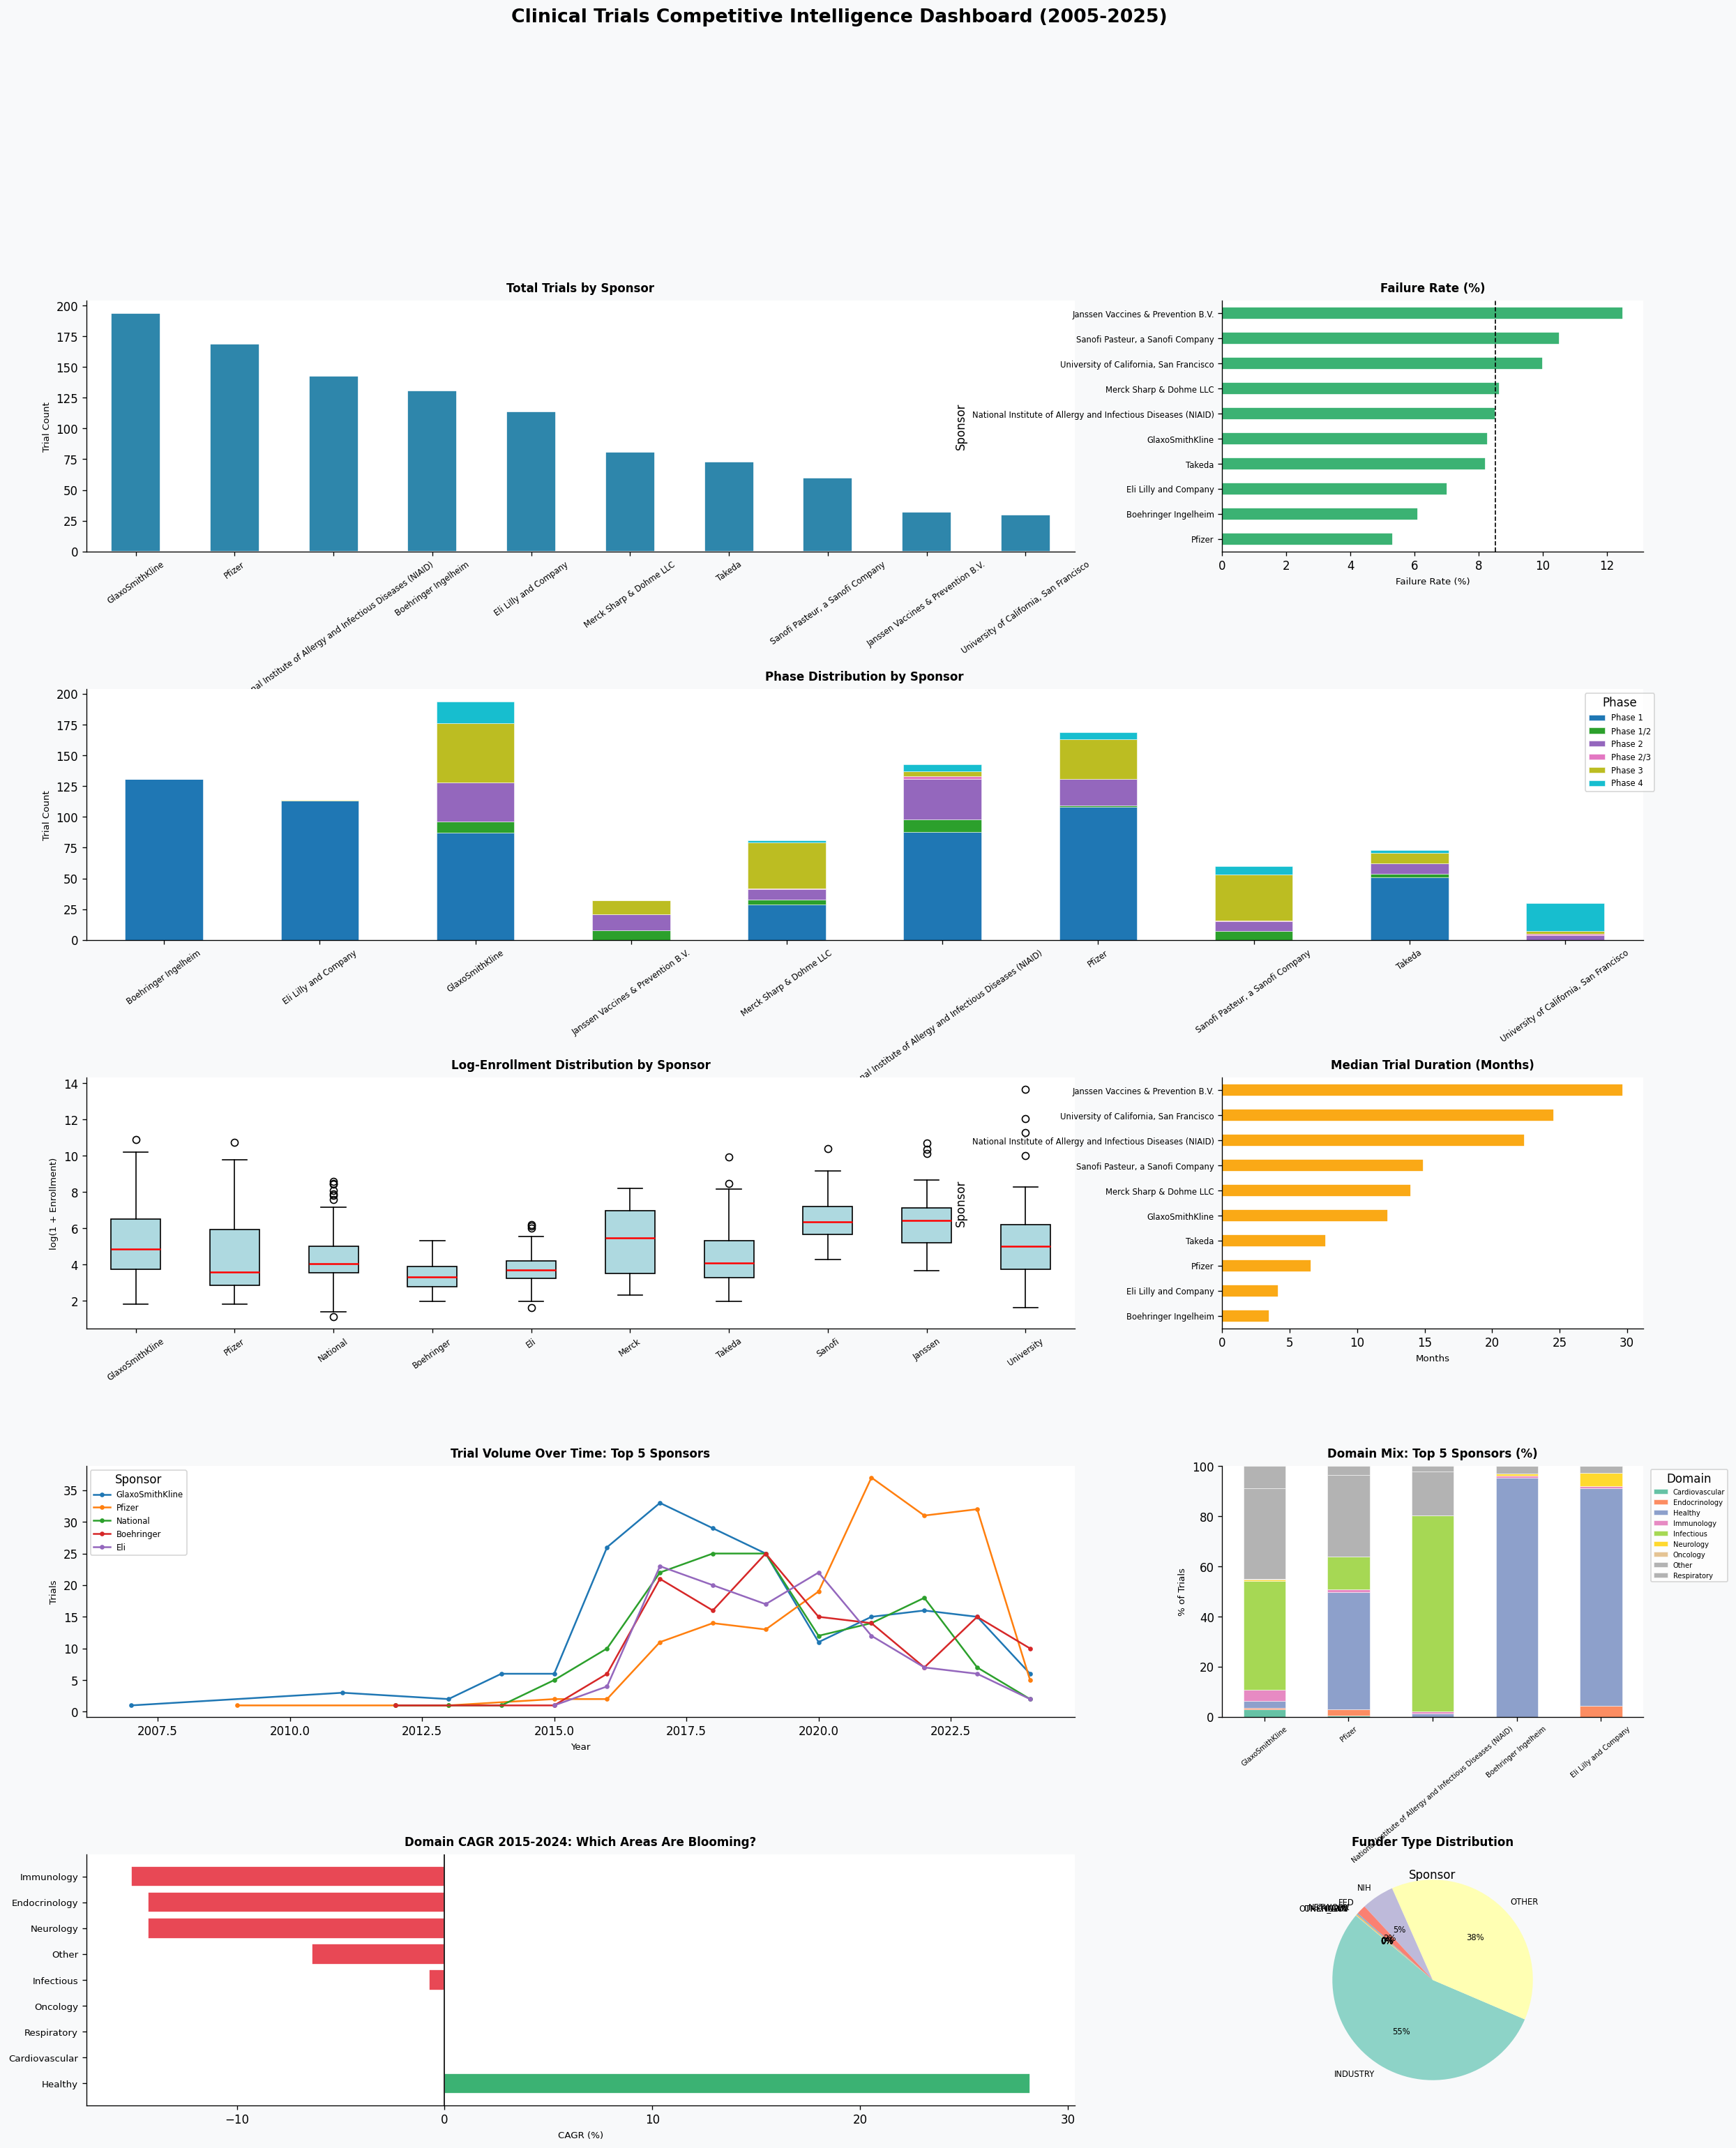

Competitive landscaping dashboard saved.


In [24]:
def plot_competitive_dashboard(df, top_n_sponsors=10):
    """
    Generates a comprehensive competitive landscaping dashboard.
    This function is reusable and will produce the full dashboard
    for any subset of the data passed to it.
    """
    top_sponsors = df["Sponsor"].value_counts().head(top_n_sponsors).index.tolist()
    df_top = df[df["Sponsor"].isin(top_sponsors)].copy()
    df_top_outcome = df_top[df_top["Status_Clean"].isin(["Completed", "Terminated"])]

    fig = plt.figure(figsize=(24, 28))
    fig.patch.set_facecolor("#F8F9FA")
    gs = gridspec.GridSpec(5, 3, figure=fig, hspace=0.55, wspace=0.35)

    title_props = {"fontsize": 10, "fontweight": "bold", "pad": 8}
    label_props = {"fontsize": 8}

    # panel 1: trial volume by sponsor
    ax1 = fig.add_subplot(gs[0, :2])
    vol = df_top["Sponsor"].value_counts().reindex(top_sponsors)
    vol.plot(kind="bar", ax=ax1, color="#2E86AB", edgecolor="white")
    ax1.set_title("Total Trials by Sponsor", **title_props)
    ax1.set_xlabel("")
    ax1.set_ylabel("Trial Count", **label_props)
    ax1.tick_params(axis="x", rotation=35, labelsize=7)

    # panel 2: failure rate by sponsor
    ax2 = fig.add_subplot(gs[0, 2])
    fail_stats = df_top_outcome.groupby("Sponsor")["Is_Failed"].mean() * 100
    fail_stats = fail_stats.reindex(top_sponsors).sort_values(ascending=True)
    colors_fail = ["#E84855" if v > 20 else "#3BB273" for v in fail_stats.values]
    fail_stats.plot(kind="barh", ax=ax2, color=colors_fail, edgecolor="white")
    ax2.axvline(fail_stats.mean(), color="black", linestyle="--", linewidth=1)
    ax2.set_title("Failure Rate (%)", **title_props)
    ax2.set_xlabel("Failure Rate (%)", **label_props)
    ax2.tick_params(axis="y", labelsize=7)

    # panel 3: phase distribution across sponsors
    ax3 = fig.add_subplot(gs[1, :])
    phase_sponsor = df_top.groupby(["Sponsor", "Phase_Clean"]).size().unstack(fill_value=0)
    phase_sponsor.plot(kind="bar", stacked=True, ax=ax3, colormap="tab10",
                       edgecolor="white", linewidth=0.3)
    ax3.set_title("Phase Distribution by Sponsor", **title_props)
    ax3.set_xlabel("")
    ax3.set_ylabel("Trial Count", **label_props)
    ax3.tick_params(axis="x", rotation=35, labelsize=7)
    ax3.legend(title="Phase", fontsize=7, bbox_to_anchor=(1.01, 1))

    # panel 4: enrollment distributions per sponsor
    ax4 = fig.add_subplot(gs[2, :2])
    enroll_data = [df_top[df_top["Sponsor"] == s]["Log_Enrollment"].dropna().values
                   for s in top_sponsors]
    ax4.boxplot(enroll_data, labels=[s.split()[0] for s in top_sponsors],
                patch_artist=True,
                boxprops=dict(facecolor="#AED9E0"),
                medianprops=dict(color="red", linewidth=1.5))
    ax4.set_title("Log-Enrollment Distribution by Sponsor", **title_props)
    ax4.set_ylabel("log(1 + Enrollment)", **label_props)
    ax4.tick_params(axis="x", rotation=35, labelsize=7)

    # panel 5: avg trial duration per sponsor
    ax5 = fig.add_subplot(gs[2, 2])
    dur = df_top.groupby("Sponsor")["Duration_Months"].median().reindex(top_sponsors).sort_values()
    dur.plot(kind="barh", ax=ax5, color="#FAA916", edgecolor="white")
    ax5.set_title("Median Trial Duration (Months)", **title_props)
    ax5.set_xlabel("Months", **label_props)
    ax5.tick_params(axis="y", labelsize=7)

    # panel 6: trial count trend (top 5 sponsors)
    ax6 = fig.add_subplot(gs[3, :2])
    top5 = df["Sponsor"].value_counts().head(5).index.tolist()
    for sponsor in top5:
        ts = df[df["Sponsor"] == sponsor].groupby("Start_Year").size()
        ax6.plot(ts.index, ts.values, marker="o", markersize=3,
                 linewidth=1.5, label=sponsor.split()[0])
    ax6.set_title("Trial Volume Over Time: Top 5 Sponsors", **title_props)
    ax6.set_xlabel("Year", **label_props)
    ax6.set_ylabel("Trials", **label_props)
    ax6.legend(fontsize=7, title="Sponsor")

    # panel 7: medical domain composition per sponsor
    ax7 = fig.add_subplot(gs[3, 2])
    dom_comp = df_top.groupby(["Sponsor", "Medical_Domain"]).size().unstack(fill_value=0)
    dom_pct = dom_comp.div(dom_comp.sum(axis=1), axis=0) * 100
    dom_pct_top = dom_pct.loc[top_sponsors[:5]]
    dom_pct_top.plot(kind="bar", stacked=True, ax=ax7, colormap="Set2",
                     edgecolor="white", linewidth=0.3)
    ax7.set_title("Domain Mix: Top 5 Sponsors (%)", **title_props)
    ax7.set_ylabel("% of Trials", **label_props)
    ax7.tick_params(axis="x", rotation=40, labelsize=6)
    ax7.legend(fontsize=6, bbox_to_anchor=(1.01, 1), title="Domain")

    # panel 8: overall domain CAGR (blooming areas)
    ax8 = fig.add_subplot(gs[4, :2])
    if len(domain_growth_df) > 0:
        colors_cagr = ["#3BB273" if c > 0 else "#E84855" for c in domain_growth_df["CAGR"]]
        ax8.barh(domain_growth_df["Domain"], domain_growth_df["CAGR"],
                 color=colors_cagr, edgecolor="white")
        ax8.axvline(0, color="black", linewidth=1)
        ax8.set_title("Domain CAGR 2015-2024: Which Areas Are Blooming?", **title_props)
        ax8.set_xlabel("CAGR (%)", **label_props)
        ax8.tick_params(axis="y", labelsize=8)

    # panel 9: funder type distribution
    ax9 = fig.add_subplot(gs[4, 2])
    funder_dist = df["Funder Type"].value_counts()
    ax9.pie(funder_dist.values, labels=funder_dist.index, autopct="%1.0f%%",
            startangle=140, textprops={"fontsize": 7},
            colors=plt.cm.Set3.colors[:len(funder_dist)])
    ax9.set_title("Funder Type Distribution", **title_props)

    fig.suptitle(
        "Clinical Trials Competitive Intelligence Dashboard (2005-2025)",
        fontsize=16, fontweight="bold", y=1.005
    )

    plt.savefig("dashboard_competitive_landscape.png", bbox_inches="tight",
                facecolor="#F8F9FA")
    plt.show()
    print("Competitive landscaping dashboard saved.")

# call the dashboard function
plot_competitive_dashboard(df, top_n_sponsors=10)

### 8. Key Insights Summary

In [25]:
print("CLINICAL TRIAL INTELLIGENCE - KEY FINDINGS")
print()

# insight 1: top sponsor by volume
print("1. Trial Volume Leaders")
top3 = df["Sponsor"].value_counts().head(3)
for s, c in top3.items():
    print(f"   - {s}: {c} trials")

# insight 2: failure analysis
print()
print("2. Failure Analysis")
df_out = df[df["Status_Clean"].isin(["Completed", "Terminated"])]
overall_fail = df_out["Is_Failed"].mean() * 100
print(f"   - Overall failure rate: {overall_fail:.1f}%")
worst_phase = df_out.groupby("Phase_Clean")["Is_Failed"].mean().idxmax()
print(f"   - Highest failure phase: {worst_phase}")

# insight 3: blooming domains
print()
print("3. Blooming Medical Domains (by CAGR)")
print(domain_growth_df[["Domain", "CAGR"]].head(3).to_string(index=False))

# insight 4: enrollment extremes
print()
print("4. Enrollment Patterns")
print(f"   - Median enrollment: {df['Enrollment'].median():.0f} participants")
print(f"   - Mean enrollment: {df['Enrollment'].mean():.0f} participants")
print(f"   - The mean is ~{df['Enrollment'].mean()/df['Enrollment'].median():.0f}x the median,")
print("     confirming that a small number of mega-trials dominate the enrollment numbers.")

# insight 5: model results
print()
print("5. Trial Failure Prediction Model")
print(f"   - Best model: {best_model_name}")
print(f"   - AUC-ROC: {results[best_model_name]['AUC']:.3f}")
print(f"   - Recall on failures: {results[best_model_name]['Recall']:.3f}")
print("   - Key drivers of failure: Sponsor historical failure rate,")
print("     trial phase, enrollment size, and duration.")

CLINICAL TRIAL INTELLIGENCE - KEY FINDINGS

1. Trial Volume Leaders
   - GlaxoSmithKline: 194 trials
   - Pfizer: 169 trials
   - National Institute of Allergy and Infectious Diseases (NIAID): 143 trials

2. Failure Analysis
   - Overall failure rate: 10.4%
   - Highest failure phase: Phase 2/3

3. Blooming Medical Domains (by CAGR)
        Domain      CAGR
       Healthy 28.168666
Cardiovascular  0.000000
   Respiratory  0.000000

4. Enrollment Patterns
   - Median enrollment: 50 participants
   - Mean enrollment: 924 participants
   - The mean is ~18x the median,
     confirming that a small number of mega-trials dominate the enrollment numbers.

5. Trial Failure Prediction Model
   - Best model: Gradient Boosting
   - AUC-ROC: 0.878
   - Recall on failures: 0.319
   - Key drivers of failure: Sponsor historical failure rate,
     trial phase, enrollment size, and duration.


### 9. Sponsor-Level Report (Reusable)
This is the reusable sponsor-level report. By changing the SPONSOR_NAME constant nd re-run the cell to generate a complete intelligence report for any sponsor in the dataset.

Report saved to: Pfizer_report.png


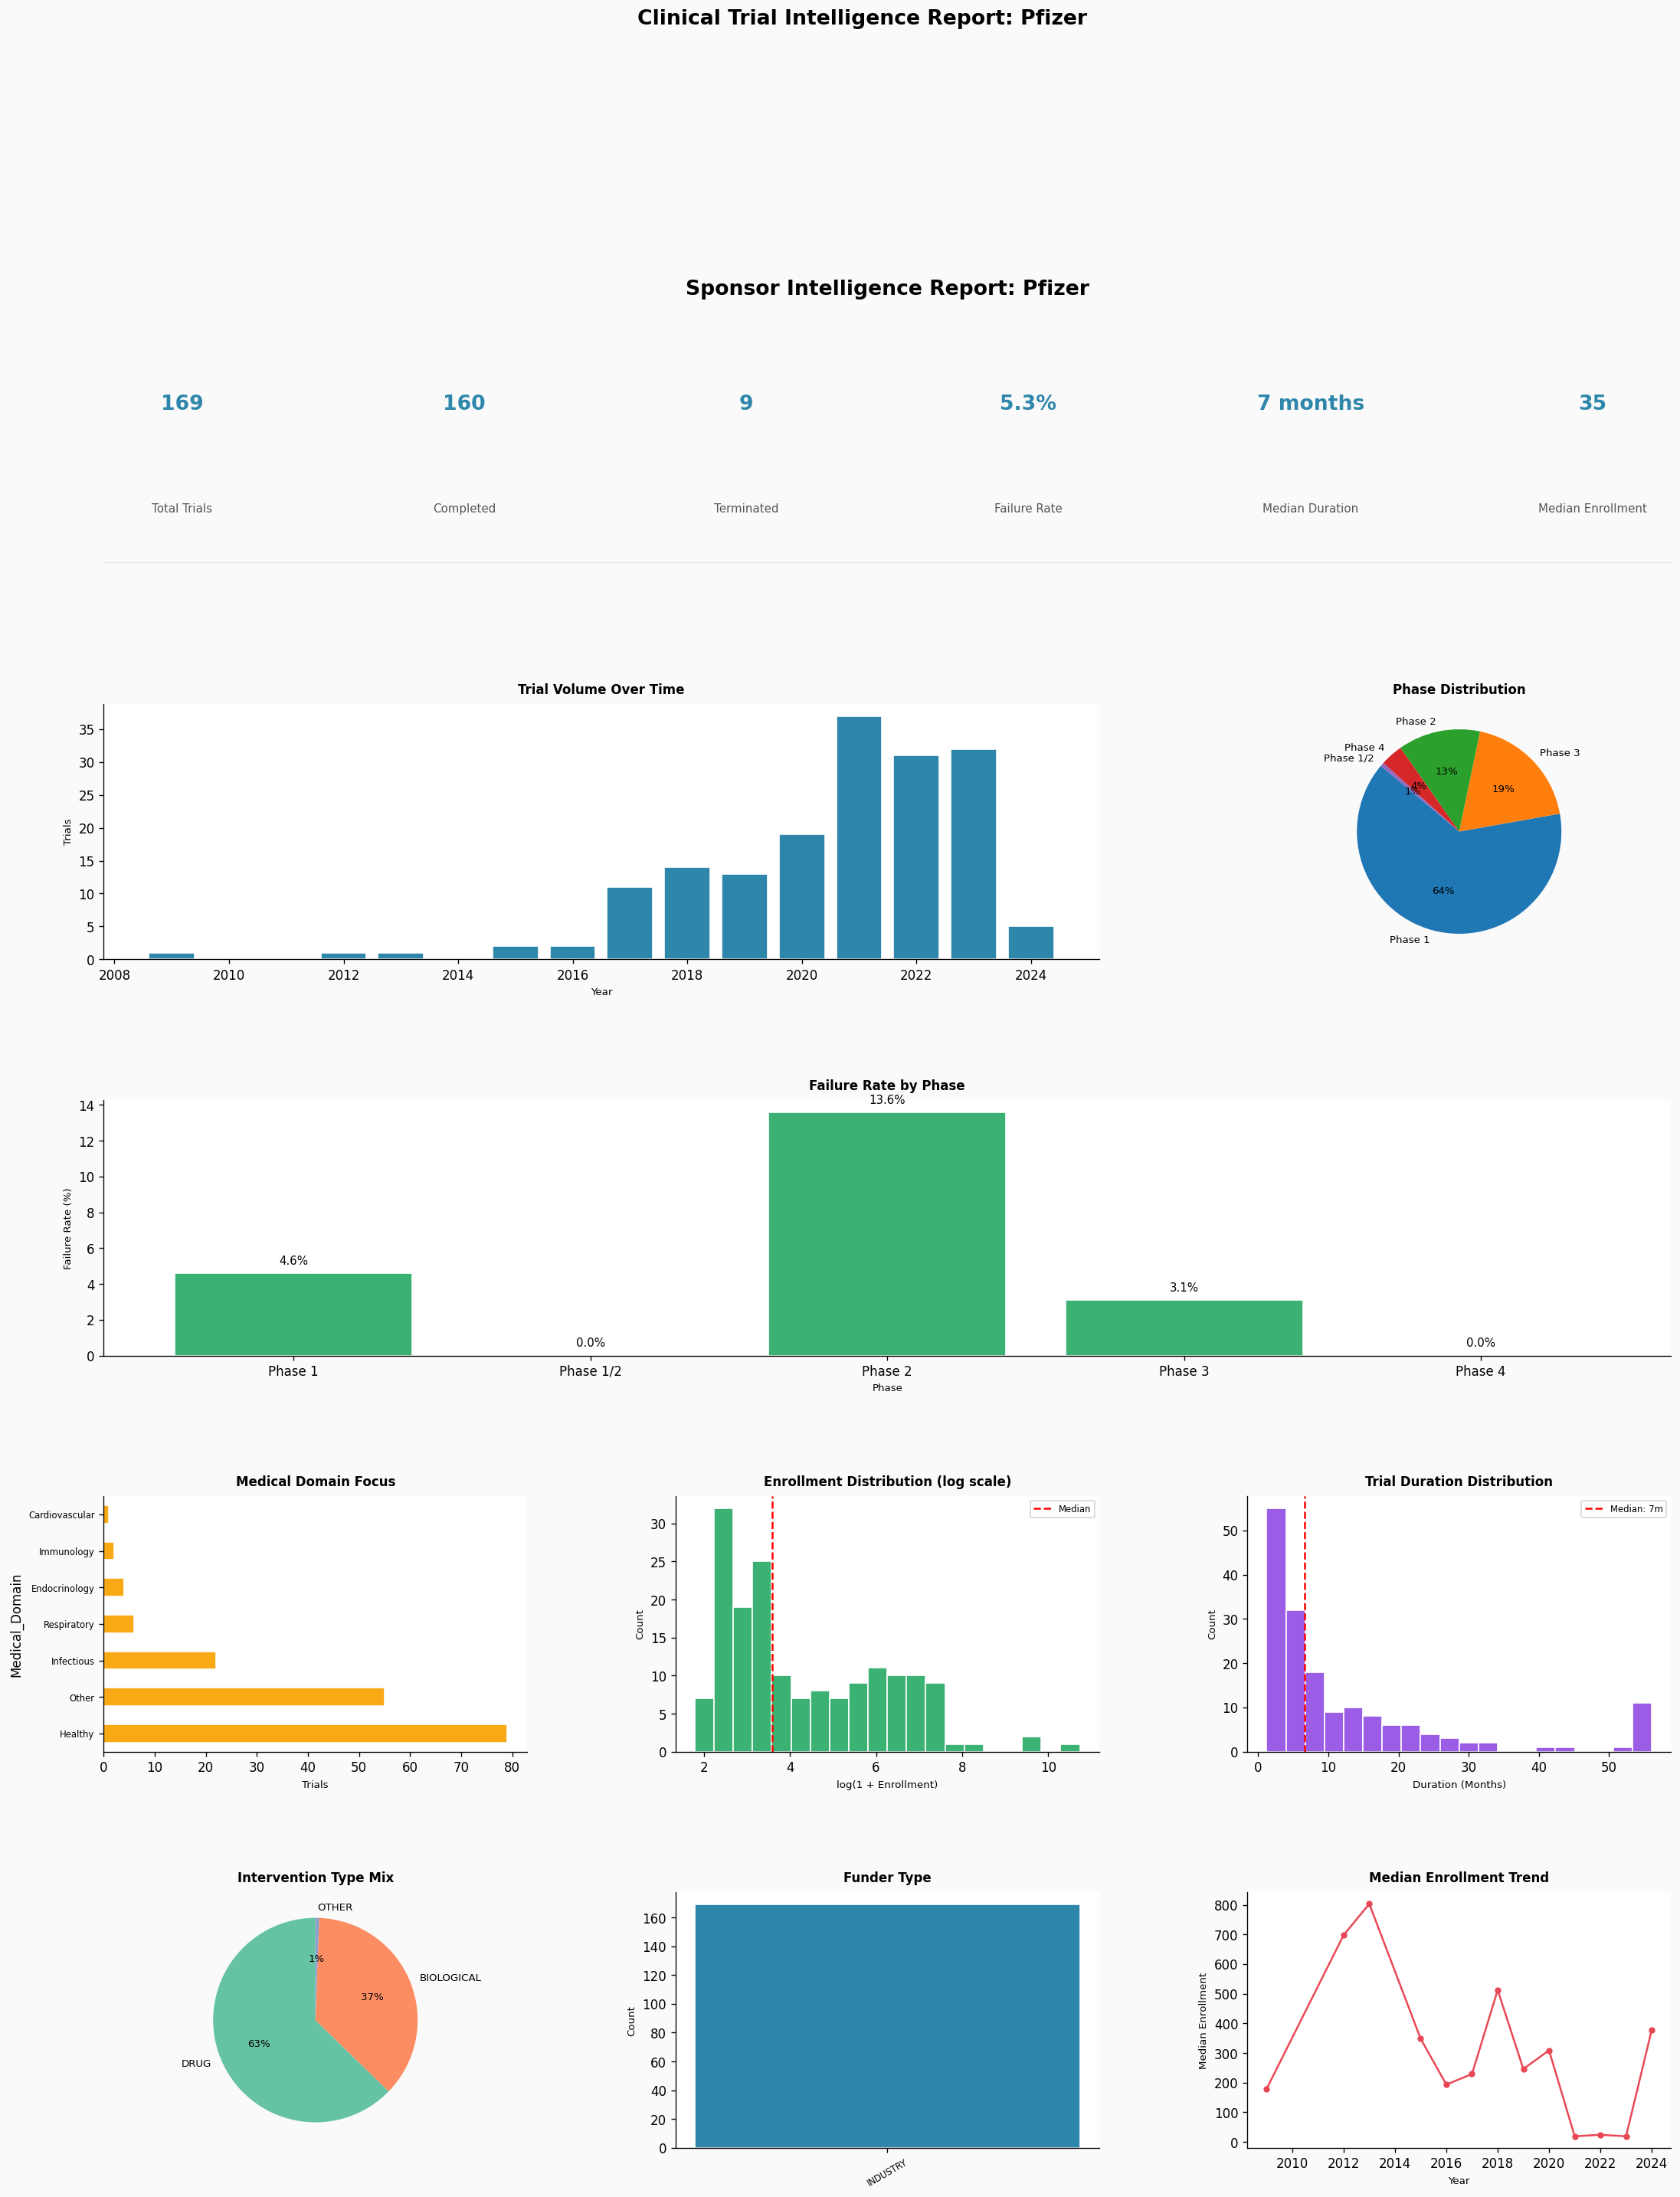

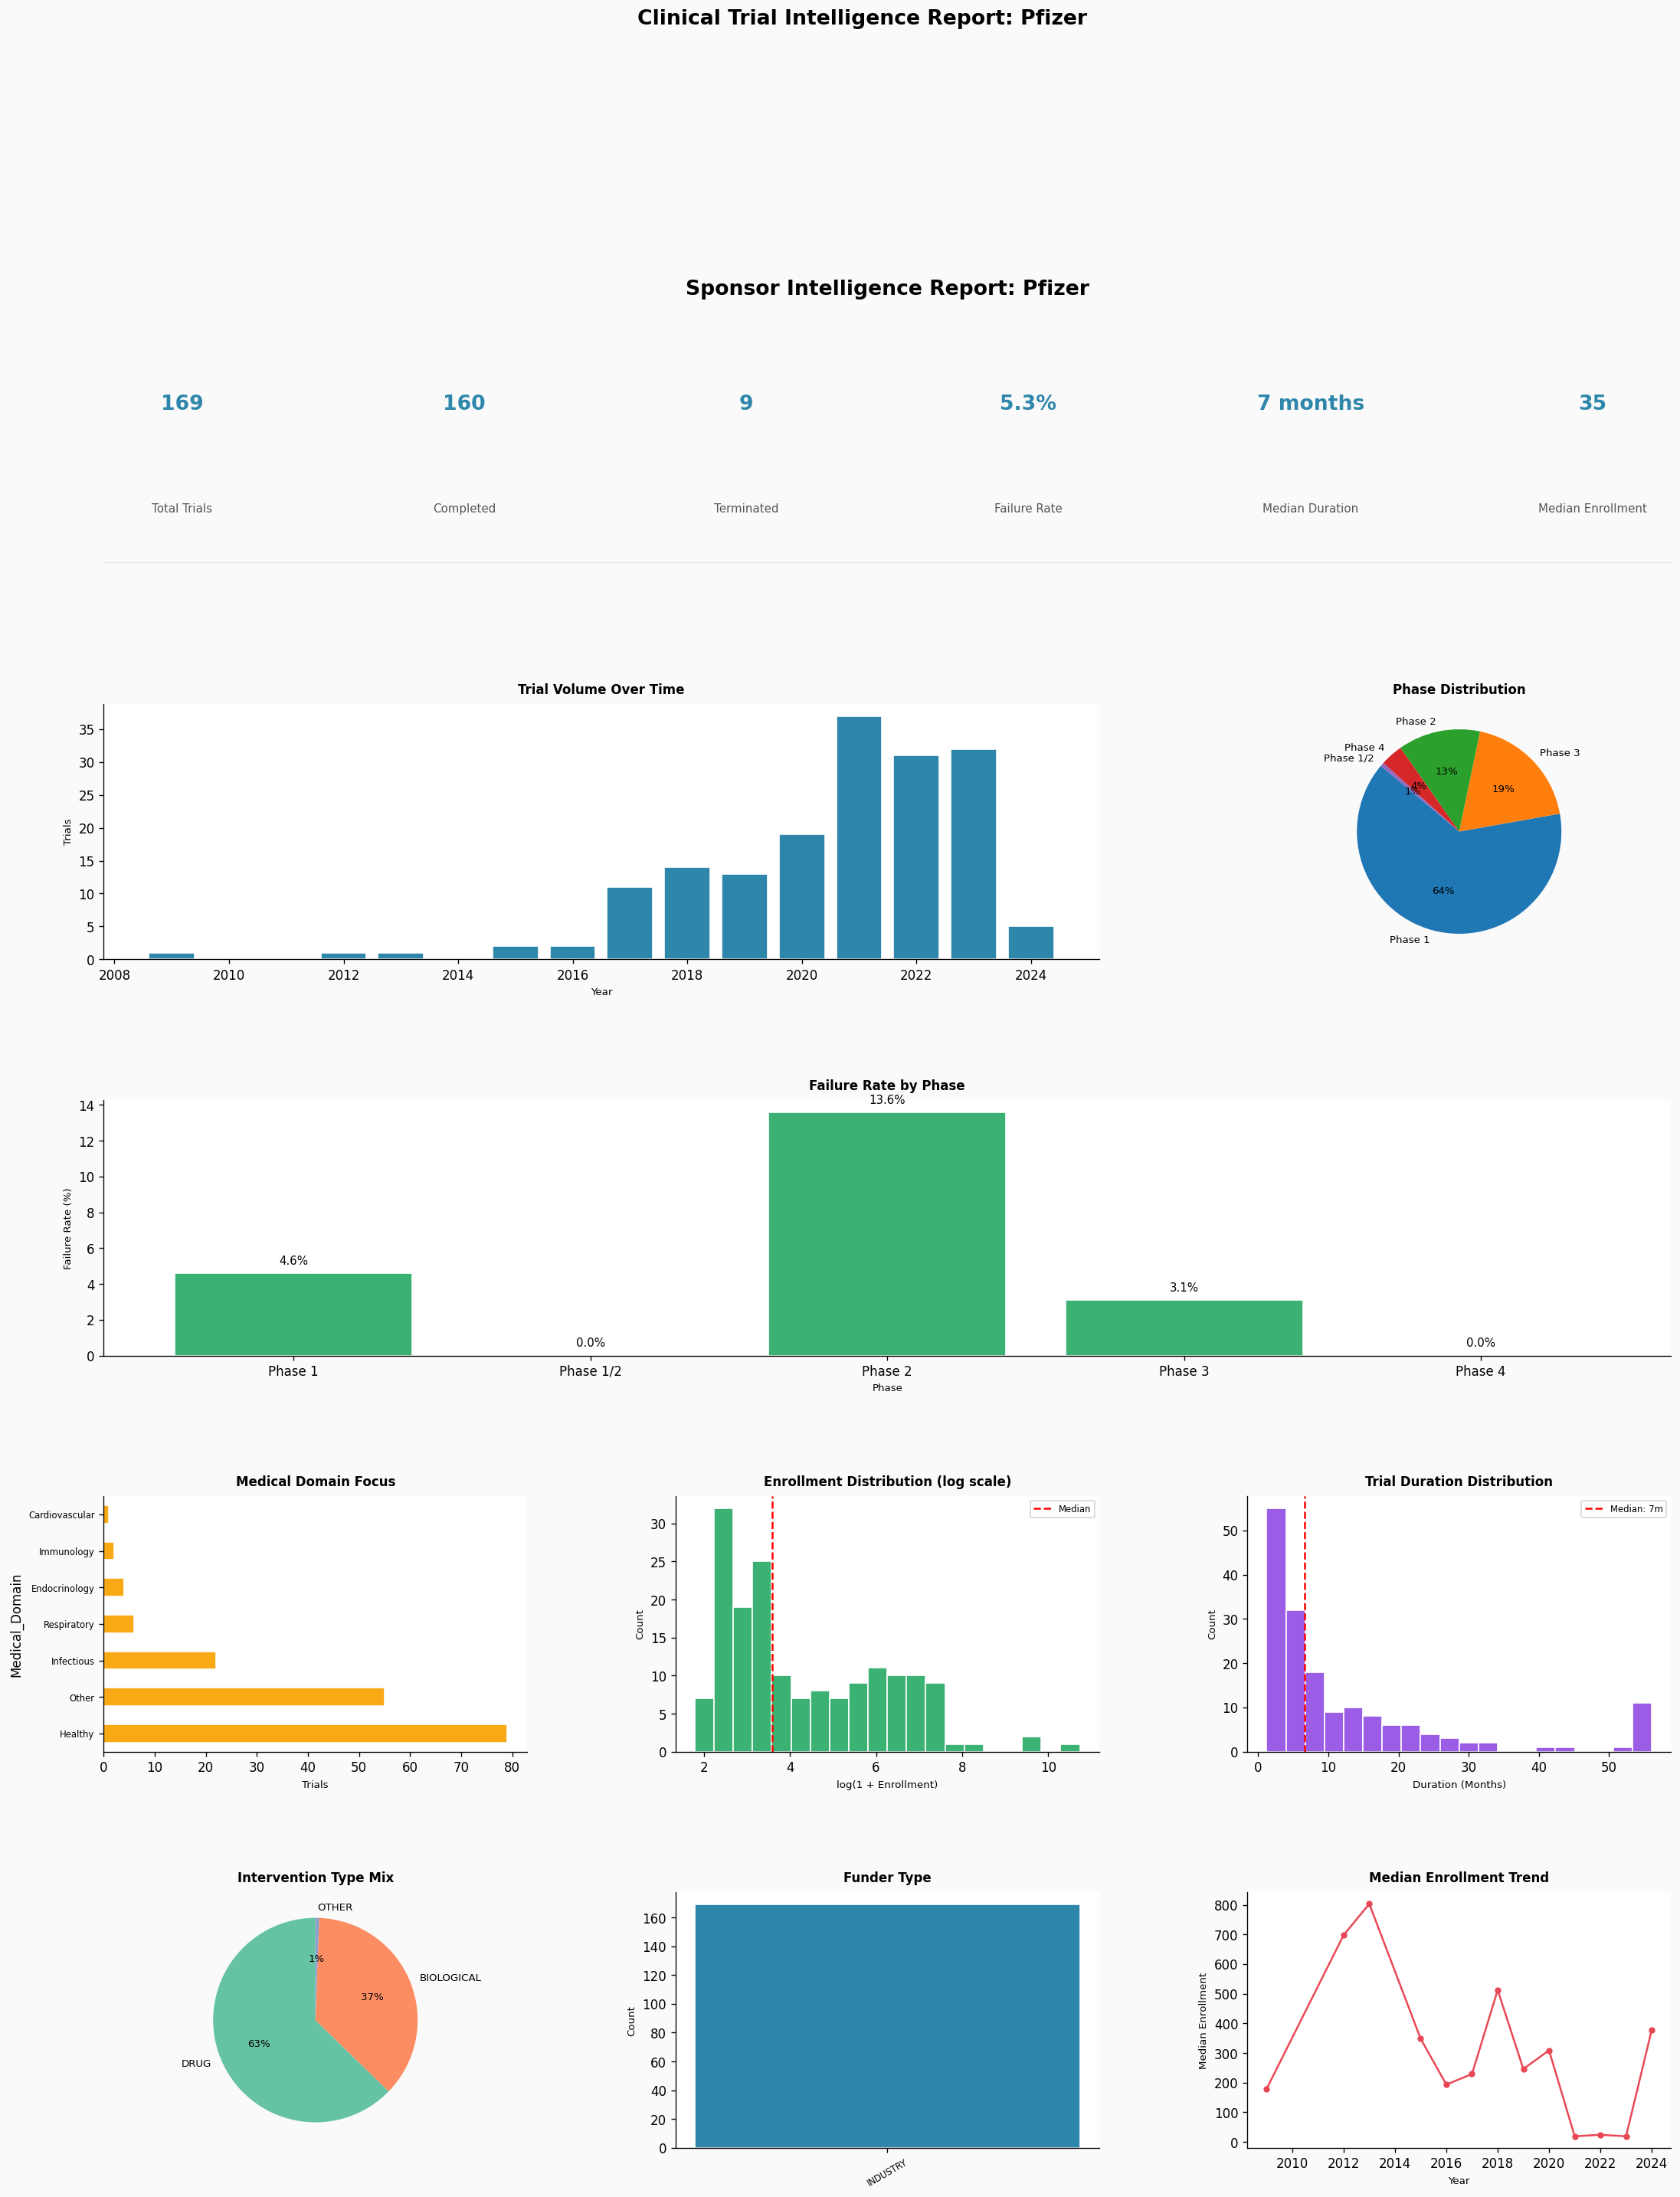

In [26]:
def generate_sponsor_report(df, sponsor_name, save_path=None):
    """
    Generates a complete sponsor-level intelligence report.

    Parameters
    ----------
    df : pd.DataFrame
        The cleaned clinical trials dataframe.
    sponsor_name : str
        Exact sponsor name as it appears in the 'Sponsor' column.
        Example: 'Pfizer', 'GlaxoSmithKline'
    save_path : str or None
        If provided, saves the figure to this path.
        Example: 'pfizer_report.png'

    Returns
    -------
    None. Displays and optionally saves the report figure.
    """

    df_sponsor = df[df["Sponsor"] == sponsor_name].copy()

    if len(df_sponsor) == 0:
        print(f"No data found for sponsor: {sponsor_name}")
        print("Available sponsors:", df["Sponsor"].value_counts().head(20).index.tolist())
        return

    df_outcome = df_sponsor[df_sponsor["Status_Clean"].isin(["Completed", "Terminated"])]
    total = len(df_sponsor)
    completed = (df_sponsor["Status_Clean"] == "Completed").sum()
    terminated = (df_sponsor["Status_Clean"] == "Terminated").sum()
    failure_rate = terminated / max(completed + terminated, 1) * 100
    avg_duration = df_sponsor["Duration_Months"].median()
    avg_enroll = df_sponsor["Enrollment"].median()

    fig = plt.figure(figsize=(22, 26))
    fig.patch.set_facecolor("#FAFAFA")
    gs = gridspec.GridSpec(5, 3, figure=fig, hspace=0.55, wspace=0.35)
    title_props = {"fontsize": 10, "fontweight": "bold", "pad": 8}

    # header metrics
    header_ax = fig.add_subplot(gs[0, :])
    header_ax.axis("off")
    metrics = [
        f"Total Trials: {total}",
        f"Completed: {completed}",
        f"Terminated: {terminated}",
        f"Failure Rate: {failure_rate:.1f}%",
        f"Median Duration: {avg_duration:.0f} months",
        f"Median Enrollment: {avg_enroll:.0f}"
    ]
    x_positions = np.linspace(0.05, 0.95, len(metrics))
    for x, metric in zip(x_positions, metrics):
        label, value = metric.split(": ")
        header_ax.text(x, 0.6, value, ha="center", fontsize=16, fontweight="bold",
                       color="#2E86AB")
        header_ax.text(x, 0.2, label, ha="center", fontsize=9, color="#555555")
    header_ax.set_title(f"Sponsor Intelligence Report: {sponsor_name}",
                        fontsize=16, fontweight="bold", pad=10)
    header_ax.axhline(0.0, color="#DDDDDD", linewidth=1)

    # panel 1: trial volume over time
    ax1 = fig.add_subplot(gs[1, :2])
    ts = df_sponsor.groupby("Start_Year").size()
    ax1.bar(ts.index, ts.values, color="#2E86AB", edgecolor="white")
    ax1.set_title("Trial Volume Over Time", **title_props)
    ax1.set_xlabel("Year", fontsize=8)
    ax1.set_ylabel("Trials", fontsize=8)

    # panel 2: phase distribution
    ax2 = fig.add_subplot(gs[1, 2])
    phase_dist = df_sponsor["Phase_Clean"].value_counts()
    ax2.pie(phase_dist.values, labels=phase_dist.index, autopct="%1.0f%%",
            startangle=140, textprops={"fontsize": 8},
            colors=plt.cm.tab10.colors[:len(phase_dist)])
    ax2.set_title("Phase Distribution", **title_props)

    # panel 3: failure rate by phase for this sponsor
    ax3 = fig.add_subplot(gs[2, :])
    if len(df_outcome) > 0:
        phase_fail = df_outcome.groupby("Phase_Clean")["Is_Failed"].agg(
            Total="count", Failed="sum"
        ).reset_index()
        phase_fail["Failure_Rate"] = (phase_fail["Failed"] / phase_fail["Total"] * 100).round(1)
        colors_p = ["#E84855" if r > 20 else "#3BB273" for r in phase_fail["Failure_Rate"]]
        bars = ax3.bar(phase_fail["Phase_Clean"], phase_fail["Failure_Rate"],
                       color=colors_p, edgecolor="white")
        for bar, rate in zip(bars, phase_fail["Failure_Rate"]):
            ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                     f"{rate}%", ha="center", fontsize=9)
        ax3.set_title("Failure Rate by Phase", **title_props)
        ax3.set_xlabel("Phase", fontsize=8)
        ax3.set_ylabel("Failure Rate (%)", fontsize=8)
    else:
        ax3.text(0.5, 0.5, "No outcome data", ha="center", va="center", transform=ax3.transAxes)

    # panel 4: medical domain breakdown
    ax4 = fig.add_subplot(gs[3, 0])
    dom_dist = df_sponsor["Medical_Domain"].value_counts()
    dom_dist.plot(kind="barh", ax=ax4, color="#FAA916", edgecolor="white")
    ax4.set_title("Medical Domain Focus", **title_props)
    ax4.set_xlabel("Trials", fontsize=8)
    ax4.tick_params(axis="y", labelsize=7)

    # panel 5: enrollment distribution
    ax5 = fig.add_subplot(gs[3, 1])
    ax5.hist(df_sponsor["Log_Enrollment"].dropna(), bins=20, color="#3BB273", edgecolor="white")
    ax5.axvline(df_sponsor["Log_Enrollment"].median(), color="red", linestyle="--",
                linewidth=1.5, label="Median")
    ax5.set_title("Enrollment Distribution (log scale)", **title_props)
    ax5.set_xlabel("log(1 + Enrollment)", fontsize=8)
    ax5.set_ylabel("Count", fontsize=8)
    ax5.legend(fontsize=7)

    # panel 6: trial duration distribution
    ax6 = fig.add_subplot(gs[3, 2])
    ax6.hist(df_sponsor["Duration_Months"].dropna().clip(upper=df_sponsor["Duration_Months"].quantile(0.95)),
             bins=20, color="#9B5DE5", edgecolor="white")
    ax6.axvline(df_sponsor["Duration_Months"].median(), color="red", linestyle="--",
                linewidth=1.5, label=f"Median: {df_sponsor['Duration_Months'].median():.0f}m")
    ax6.set_title("Trial Duration Distribution", **title_props)
    ax6.set_xlabel("Duration (Months)", fontsize=8)
    ax6.set_ylabel("Count", fontsize=8)
    ax6.legend(fontsize=7)

    # panel 7: intervention types
    ax7 = fig.add_subplot(gs[4, 0])
    int_dist = df_sponsor["Intervention_Type"].value_counts()
    ax7.pie(int_dist.values, labels=int_dist.index, autopct="%1.0f%%",
            startangle=90, textprops={"fontsize": 8},
            colors=plt.cm.Set2.colors[:len(int_dist)])
    ax7.set_title("Intervention Type Mix", **title_props)

    # panel 8: funder type
    ax8 = fig.add_subplot(gs[4, 1])
    funder_dist = df_sponsor["Funder Type"].value_counts()
    ax8.bar(funder_dist.index, funder_dist.values, color="#2E86AB", edgecolor="white")
    ax8.set_title("Funder Type", **title_props)
    ax8.set_xlabel("", fontsize=8)
    ax8.set_ylabel("Count", fontsize=8)
    ax8.tick_params(axis="x", rotation=30, labelsize=7)

    # panel 9: enrollment trend
    ax9 = fig.add_subplot(gs[4, 2])
    enroll_trend = df_sponsor.groupby("Start_Year")["Enrollment"].median()
    ax9.plot(enroll_trend.index, enroll_trend.values, "o-", color="#E84855",
             linewidth=1.5, markersize=4)
    ax9.set_title("Median Enrollment Trend", **title_props)
    ax9.set_xlabel("Year", fontsize=8)
    ax9.set_ylabel("Median Enrollment", fontsize=8)

    fig.suptitle(
        f"Clinical Trial Intelligence Report: {sponsor_name}",
        fontsize=16, fontweight="bold", y=1.005
    )

    if save_path:
        plt.savefig(save_path, bbox_inches="tight", facecolor="#FAFAFA")
        print(f"Report saved to: {save_path}")

    plt.show()
    return fig


# to use: just change the SPONSOR_NAME below and re-run this cell
SPONSOR_NAME = "Pfizer"
generate_sponsor_report(df, SPONSOR_NAME, save_path=f"{SPONSOR_NAME.replace(' ', '_')}_report.png")

### 10: Making the Model Reusable with FastAPI
We now wrap the trained Gradient Boosting model into a production API. The model receives trial characteristics as input and returns a failure probability.

In [27]:
# save model artifacts for the API
import joblib

joblib.dump(gb, "model_gb.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(le_intervention, "le_intervention.pkl")
joblib.dump(le_domain, "le_domain.pkl")
joblib.dump(FEATURE_COLS, "feature_cols.pkl")

print("Model artifacts saved:")
print("  - model_gb.pkl")
print("  - scaler.pkl")
print("  - le_intervention.pkl")
print("  - le_domain.pkl")
print("  - feature_cols.pkl")

Model artifacts saved:
  - model_gb.pkl
  - scaler.pkl
  - le_intervention.pkl
  - le_domain.pkl
  - feature_cols.pkl
